In [ ]:
pip install duckdb pandas numpy matplotlib Pyarrow 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np

In [2]:
import duckdb


In [3]:
## LOAD AND FILTER the main energy levels database

In [5]:
# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None


def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        conn = duckdb.connect('energylevels2.duckdb')
        df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-' and J < 165 and v < 42 ORDER BY energy" 
            ).df()
        conn.close()
        
        energies_cm = list(df.energy)
        J_vals = list(df.J)
        energies_m = [(energy_cm + 794.590195753252-791.716307 ) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")
    
    return Q_val

In [22]:
conn = duckdb.connect('energylevels2.duckdb')

df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-'  ORDER BY energy"
            ).df()[['v', 'J', 'lambda', 'sigma', 'omega'
]].drop_duplicates().shape[0]
df

IOException: IO Error: Could not set lock on file "/storage/project/r-js130-0/pagrawala6/thesisplots/energylevels2.duckdb": Conflicting lock is held in /storage/pace-apps/manual/packages/anaconda3/2023.03/bin/python3.10 (PID 1289786). See also https://duckdb.org/docs/stable/connect/concurrency

In [7]:
Q(300)

Loaded 10306 energy levels


218.49885813081738

In [7]:
ls -lh

total 2.9G
-rw-r--r--. 1 pagrawala6 pace-js130 1.3K Aug 23 17:46  Lu_2010.csv
-rw-r--r--. 1 pagrawala6 pace-js130 1.3K Aug 23 17:46  Yoshino_2005.csv
-rw-r--r--. 1 pagrawala6 pace-js130  39K Nov  4 22:37  cross_section.pdf
-rw-r--r--. 1 pagrawala6 pace-js130 224K Nov  4 22:38  cross_section.png
-rw-r--r--. 1 pagrawala6 pace-js130 1.7G Aug 23 17:46 'duo_oxygen1616_schumannrunge_corrected2 (1).duckdb'
-rw-r--r--. 1 pagrawala6 pace-js130 418M Aug 23 17:46  duo_oxygen1616_schumannrunge_corrected2.duckdb
-rw-r--r--. 1 pagrawala6 pace-js130  12K Feb  4 12:26  duo_oxygen1616_schumannrunge_corrected2_newpot.duckdb
-rw-r--r--. 1 pagrawala6 pace-js130 469M Feb  4 12:26  duo_oxygen1616_schumannrunge_newpot.duckdb
-rw-r--r--. 1 pagrawala6 pace-js130 1.1M Aug 23 17:46  energylevels2.duckdb
-rw-r--r--. 1 pagrawala6 pace-js130 1.1M Feb 18 11:29  main.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 421K Feb 11 13:01  main2.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130  55K Feb  4 12:25  o2_cross_section_compari

In [18]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/"

/storage/project/r-js130-0/pagrawala6/thesisplots


In [19]:
full_conn = duckdb.connect("duo_oxygen1616_schumannrunge_corrected2.duckdb")

In [6]:
# is this above the dissociation limit?

print (f'The dissociation limit, as specified in the input B state PEC, is 57830 cm^-1 whereas the minimum energy of the upper state in the contiuum database is:')
full_conn.execute("SELECT MIN(up_energy) AS min_up_energy FROM duo_oxygen1616_schumannrunge").df()



# Does this mean that our filters on the probability density are NOT tight enough?\n ")


The dissociation limit, as specified in the input B state PEC, is 57830 cm^-1 whereas the minimum energy of the upper state in the contiuum database is:


,min_up_energy
0,49356.3777


## BEGIN Main database queries for all computations: 
Note that any filters on the transitions to be used have to be applied AT this step, say restricting the v, J, up_energy etc. 
#### REMEMBER to also synchronize the same filters with the energy levels database

In [20]:
# continuum = full_conn.execute("""
# SELECT *
# FROM duo_oxygen1616_schumannrunge where down_energy < 42025 and down_J < 121 and down_v < 26 and up_energy > 57840
# """).df()
continuum = full_conn.execute("""
SELECT *
FROM duo_oxygen1616_schumannrunge where down_energy < 42025 and down_J < 125 and down_v < 25 and up_energy > 57840
""").df()
# note that continuum IS filtered at this time  - Bound X states only


# discrete = full_conn.execute("""
# SELECT *
# FROM duo_oxygen1616_schumannrunge where down_J<150 and down_v<30
# """).df()
# discrete


In [8]:
# get max and min of line_pos
max_line_pos = continuum["line_pos"].max()
min_line_pos = continuum["line_pos"].min()

print(f"Maximum line_pos: {max_line_pos}")
print(f"Minimum line_pos: {min_line_pos}")

Maximum line_pos: 119999.9206
Minimum line_pos: 16243.5019


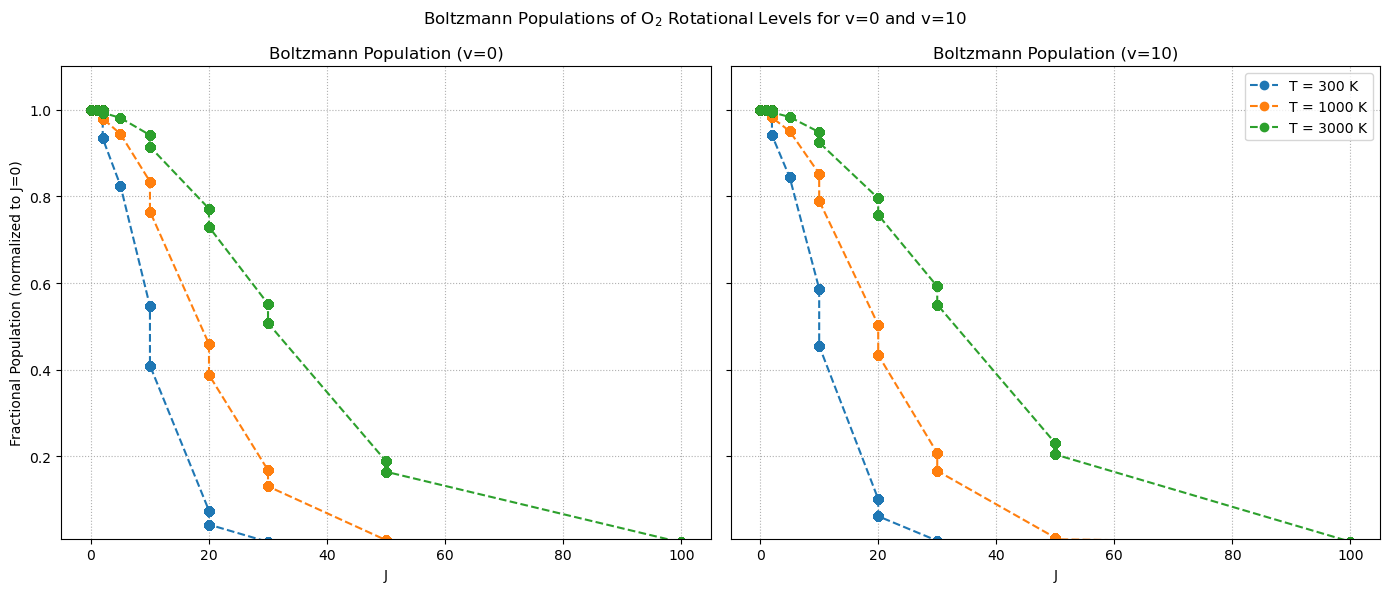

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
k_B = 0.69503476  # cm^-1/K (Boltzmann constant in spectroscopic units)
T_list = [300, 1000, 3000]
J_values = [0, 1, 2, 5, 10, 20, 30, 50, 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for idx, v in enumerate([0, 10]):
    v_df = continuum[continuum["down_v"] == v]
    subset = v_df[v_df["down_J"].isin(J_values)].copy()

    for T in T_list:
        # Boltzmann factor
        subset[f"pop_T{T}"] = np.exp(-subset["down_energy"] / (k_B * T))

        # Normalize wrt J=0 population
        norm_factor = subset[subset["down_J"] == 0][f"pop_T{T}"].values[0]
        subset[f"pop_T{T}_frac"] = subset[f"pop_T{T}"] / norm_factor

        # Plot
        axes[idx].plot(
            subset["down_J"],
            subset[f"pop_T{T}_frac"],
            linestyle="--",
            marker="o",
            label=f"T = {T} K"
        )

    axes[idx].set_xlabel("J")
    axes[idx].set_title(f"Boltzmann Population (v={v})")
    axes[idx].grid(True, which="both", linestyle=":")
    axes[idx].set_ylim(0.01, 1.1)

axes[0].set_ylabel("Fractional Population (normalized to J=0)")
axes[1].legend()
fig.suptitle("Boltzmann Populations of O$_2$ Rotational Levels for v=0 and v=10")
plt.tight_layout()
plt.show()

## Begin "grouping" by lower energy level

In [21]:
# num_unique_lower_levelsd = discrete[[
#     'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
# ]].drop_duplicates().shape[0]
# num_unique_lower_levelsc = continuum[[
#     'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
# ]].drop_duplicates().shape[0]    
num_unique_lower_levelsc = continuum[[
    'down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy'
]].drop_duplicates().shape[0]


levels = conn.execute("""
SELECT *
FROM energy_levels where J<151 and v<26 and el_state = 'X3Sigma-'
""").df()

num_X_levels = levels[[
    'v', 'J', 'lambda', 'sigma', 'omega',
]].drop_duplicates().shape[0]



print(f"Number of unique lower levels continuum:{num_unique_lower_levelsc} and Number of unique lower levels discrete:__ BUT in the energy levels database = {num_X_levels}" , ) # Ensure that the number here matches the "parse_levels" code for the partition function




NameError: name 'conn' is not defined

In [23]:

continuum_grouped = continuum.groupby(
    ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
).agg({
    'A': list,
    'line_pos': list,
    'up_energy': list,      # optional, if you want to retain upper state quantum numbers
    'up_J': list,
    'up_v': list
    # add more columns as needed
}).reset_index()

# discrete_grouped = discrete.groupby(
#     ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
# ).agg({
#     'A': list,
#     'line_pos': list,
#     'up_energy': list,      # optional, if you want to retain upper state quantum numbers
#     'up_J': list
#     # add more columns as needed
# }).reset_index()




continuum_grouped

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,A,line_pos,up_energy,up_J,up_v
0,0,0.0,0.0,0.0,0.0,2.8652,"[31.3179497, 0.127445465, 106183.166, 978.7402...","[118172.6855, 111804.7128, 60249.8545, 84696.1...","[118175.5507, 111807.578, 60252.7197, 84699.05...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[223, 210, 53, 145, 93, 67, 132, 184, 197, 40,..."
1,0,1.0,0.0,1.0,1.0,2.8652,"[2017.63368, 2936.2206, 188.694824, 3007319.91...","[94645.5068, 84696.1878, 89516.3646, 68678.825...","[94648.372, 84699.053, 89519.2297, 68681.6902,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[171, 145, 158, 93, 40, 223, 210, 53, 106, 119..."
2,0,2.0,0.0,0.0,0.0,17.1904,"[1.94402915e-17, 1.23562439e-22, 287139.301, 1...","[80173.8272, 111790.3876, 60235.5293, 72339.52...","[80191.0176, 111807.578, 60252.7197, 72356.712...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[132, 210, 53, 106, 184, 119, 67, 80, 93, 197,..."
3,0,2.0,0.0,1.0,1.0,2.8652,"[5325042.3, 1130641.93, 421.602317, 289063.372...","[76080.8638, 62691.9383, 105785.5101, 80188.15...","[76083.7289, 62694.8035, 105788.3753, 80191.01...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[119, 67, 197, 132, 106, 223, 158, 40, 171, 14..."
4,0,3.0,0.0,1.0,1.0,17.1904,"[5099006.64, 7128837.05, 404.801955, 2053.6729...","[76069.4508, 72341.7361, 105775.0983, 100058.7...","[76086.6412, 72358.9266, 105792.2887, 100075.9...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...","[119, 106, 197, 184, 132, 80, 223, 67, 158, 93..."
...,...,...,...,...,...,...,...,...,...,...,...
4590,24,103.0,0.0,1.0,1.0,41294.8575,"[3955.44204, 59842.7535, 65370.7647, 326794.13...","[23979.6669, 26784.7538, 42304.4165, 63002.369...","[65274.5244, 68079.6113, 83599.274, 104297.227...","[102.0, 102.0, 102.0, 102.0, 102.0, 102.0, 102...","[63, 76, 128, 180, 102, 193, 24, 219, 50, 206,..."
4591,24,104.0,0.0,0.0,0.0,41673.4458,"[20521.0741, 804179.951, 2.85881196e-21, 1.908...","[87386.8952, 74570.3316, 21255.7003, 80842.552...","[129060.3409, 116243.7774, 62929.146, 122515.9...","[103.0, 103.0, 103.0, 103.0, 103.0, 103.0, 103...","[230, 205, 50, 218, 102, 193, 128, 180, 76, 36..."
4592,24,104.0,0.0,1.0,1.0,41294.8575,"[58445.4222, 6.03344928e-05, 0.00149854617, 44...","[81221.1403, 87765.4834, 74948.9199, 21634.288...","[122515.9978, 129060.3409, 116243.7774, 62929....","[103.0, 103.0, 103.0, 103.0, 103.0, 103.0, 103...","[218, 230, 205, 50, 193, 76, 115, 167, 154, 12..."
4593,24,105.0,0.0,1.0,1.0,41673.4458,"[17234.4095, 850019.807, 40660.8858, 68021.101...","[87997.7143, 75067.83, 21382.0078, 81604.5138,...","[129671.1601, 116741.2758, 63055.4536, 123277....","[104.0, 104.0, 104.0, 104.0, 104.0, 104.0, 104...","[231, 206, 50, 219, 63, 102, 193, 180, 24, 76,..."


Text(0.5, 1.0, 'Einstein A vs Wavelength (nm) - Continuum Only')

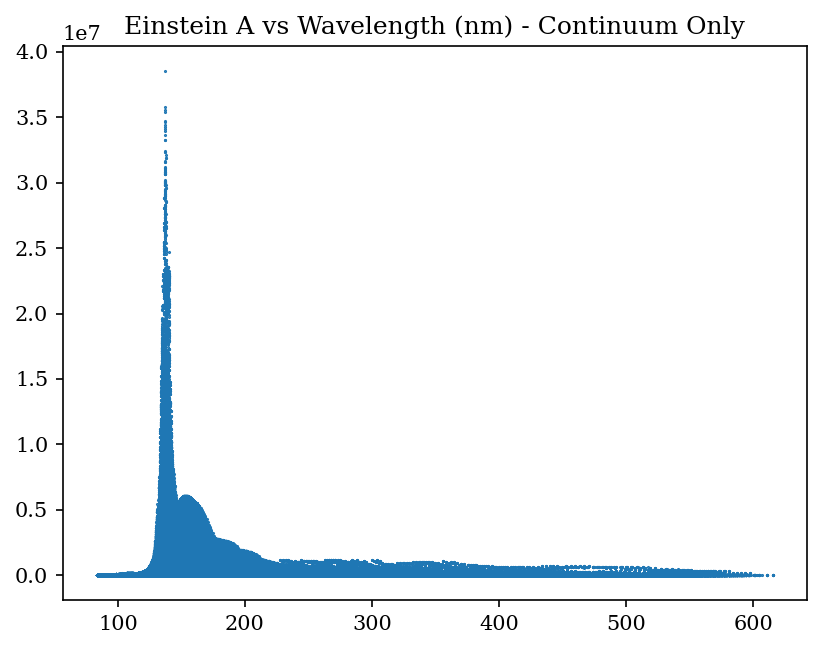

In [24]:
plt.plot(1e7/continuum['line_pos'], continuum['A'], '.', markersize=1)
plt.title("Einstein A vs Wavelength (nm) - Continuum Only")

In [25]:
down_J_list = continuum_grouped['down_J'].tolist()
down_energy_list = continuum_grouped['down_energy'].tolist()

# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None

def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        
        
        energies_cm = list(down_energy_list)
        J_vals = list(down_J_list)
        energies_m = [(energy_cm) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")


    
    return Q_val


In [26]:
print(Q(3000))
Q(300)

Loaded 4595 energy levels
4246.987587677898


219.15320394883017

In [27]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 300  # Temperature in Kelvin
Q_T = Q(T)  # Partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    cutoff_range = 2.8 * alpha_D
    
    # Vectorized computation for this chunk
    # Create 2D arrays: (n_transitions, n_frequencies)
    nu_grid = nu_range[np.newaxis, :]  # Shape: (1, n_freq)
    pos_grid = line_positions[:, np.newaxis]  # Shape: (n_trans, 1)
    
    # Apply frequency masking: only compute within cutoff range
    mask = np.abs(nu_grid - pos_grid) <= cutoff_range
    
    # Compute Gaussian contributions only where mask is True
    distances = nu_grid - pos_grid
    gaussians = np.zeros_like(distances)
    
    # Only compute Gaussian where mask is True (keeps your masking logic)
    gaussians[mask] = (np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * 
                      np.exp(-np.log(2) * distances[mask]**2 / alpha_D**2))
    
    # Weight by intensities and sum along transition axis
    weighted = gaussians * intensities[:, np.newaxis]
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity in zip(line_positions, intensities):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 2.8 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        
        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    alpha_D,
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    for i, alpha_D in enumerate(alpha_D_list):
        # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
        start_time = time.time()
        
        cross_section = compute_cross_section_optimized(
            line_positions, intensities, nu_range, alpha_D, 
            num_chunks, num_threads
        )
        
        cross_section_list.append(cross_section)
        
        total_time = time.time() - start_time
        # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list



In [28]:
# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print(f"Alpha_D values: {alpha_D_list}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list




if __name__ == "__main__":
    # alpha_D_list = [300,1500, 3000, 5000] 
    alpha_D_list = [0.003, 3,30] 
    alpha_D_list = [30,300] 
    alpha_D_list = [15] 
    alpha_D_list = [30,150] 
    alpha_D_list = [160] 


    nu_range = np.linspace(1e7/180, 1e7/100, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/550, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/750, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/600, 1e7/90, 6000)  # in cm⁻¹
    nu_range = np.linspace(1e7/200, 1e7/110, 1000)  # in cm⁻¹
    continuum['Intensity'] = 0
    continuum['Intensity'] = continuum['A'] * (2 * continuum['up_J'] + 1) * np.exp(-(h*c*(continuum['down_energy']-2.86)/(k_B * T)))  / (8.0 * np.pi*c * continuum['line_pos']**(2) * Q_T)
    

    df = continuum.sort_values(by='line_pos', ascending=True)
    
    line_positions = df['line_pos'].values
    intensities = df['Intensity'].values
    
    
    cross_section_list = []
    # CALLING THE MAIN CROSS-SECTION FUNCTION:
    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 40)
    
    
    # doing 4 chunks at this time, can decrease if each "list" is smaller or larger, remember that each "chunk" is then parallelized, so chunks are really number of passes

Starting computation with 4,816,414 transitions
Frequency range: 50000.0 to 90909.1 cm⁻¹
Alpha_D values: [160]

Total computation time: 3.93s
Cross-section shapes: [(1000,)]


In [29]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import io

def plot_exomol_o2_cross_section(temperature):
    """
    Fetches, parses, and plots O2 photodissociation cross-sections
    from ExoMol for a given temperature.
    """
    # 1. Construct the URL for the desired temperature
    url = f"https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__{temperature}__0__0.1.photo"
    print(f"Fetching data for T = {temperature} K from {url}")

    try:
        # 2. Fetch the data
        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes (404, 500, etc.)

        # 3. Use io.StringIO to treat the text content as a file in memory
        #    The data is whitespace-delimited.
        data_file = io.StringIO(response.text)

        # 4. Load the data directly into NumPy arrays
        #    The first column is wavelength (nm), the second is cross-section (cm^2)
        wavelength, cross_section = np.loadtxt(data_file, unpack=True)
        
        # 5. Plot for validation
        # plt.style.use('seaborn-v0_8-whitegrid')
        # fig, ax = plt.subplots(figsize=(10, 6))

        # ax.plot(wavelength, cross_section)

        # ax.set_xlabel('Wavelength (nm)')
        # ax.set_ylabel(r'Cross Section ($cm^{2} \, molecule^{-1}$)')
        # ax.set_title('Absorption Cross Section vs Wavelength (T = 3000 K)')
        # ax.grid(True, which="both", ls="--")
        # ax.set_xlim(130, 180)
        # ax.set_ylim(1e-20, 0.5e-16)
        # ax.set_yscale('log') # Cross-sections often span many orders of magnitude

        # plt.show()
        return wavelength, cross_section

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Run the function for a specific temperature ---
plot_exomol_o2_cross_section(temperature=300)

Fetching data for T = 300 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__300__0__0.1.photo


(array([ 50. ,  50.1,  50.2, ..., 499.8, 499.9, 500. ]),
 array([2.17e-22, 1.48e-22, 8.37e-23, ..., 1.79e-80, 1.76e-80, 1.74e-80]))

In [30]:
import duckdb

import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np   # (already imported earlier, but kept for completeness)
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from multiprocessing import Pool, cpu_count
from functools import partial
import time
validation_data = pd.read_csv('Yoshino_2005.csv')
validation_x = validation_data.iloc[:, 0]
validation_y = validation_data.iloc[:, 1]

validation_data = pd.read_csv('Lu_2010.csv')
validation_x_3 = validation_data.iloc[:, 0]
validation_y_3 = validation_data.iloc[:, 1]

validation_x_2,validation_y_2 = plot_exomol_o2_cross_section(T)

# === Plot ===
# fig, ax = plt.subplots(figsize=(12, 4.5))
fig, ax = plt.subplots(figsize=(7, 4))
fig, ax = plt.subplots(figsize=(5.5, 3.5))

ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=11)
# ax.set_title(f'Absorption Cross Section vs Wavelength (T = {T} K)')
ax.set_xlim(130, 180)
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

# Plot model spectra for each alpha_D
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    ax.plot(1e7 / nu_range, cs, label=fr'Duo, $\alpha_D$ = {alpha_D} cm$^{{-1}}$', linestyle = "-")
    # integrate cross section vs frequency (nu_range)
    integrated_cs = np.trapz(cs, nu_range)
    
    
    # print result with nice variable name
    print(f"Integrated cross-section for α_D={alpha_D}: {integrated_cs:.4e}")

# for alpha_D, cs in zip(alpha_D_list, cross_section_list2):
#     ax.plot(1e7 / nu_range, cs, label=fr'Model ($\alpha_D1$ = {alpha_D} cm$^{{-1}}$)', linestyle = "--")
# Validation data with error bars
ax.errorbar(validation_x, validation_y,
            yerr=0.3 * validation_y,
            fmt='o', markersize=4,markerfacecolor='none',
            color='black', label='Yoshino (2005)')
            
ax.plot(validation_x_2, validation_y_2,
            color='red', label='Exomol database', linestyle = "--")           

# Customize ticks
# --- Set font size for tick labels ---
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(False)

# --- Set font size for legend ---
ax.legend(loc='upper center', bbox_to_anchor=(0.5, +01.1), ncol=2, fontsize=7)


# Use tight_layout to ensure labels don't overlap
plt.tight_layout()
# plt.savefig(f'o2_cross_section_comparison_T{T}_final.png', dpi=600)
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'Yoshino_2005.csv'

Integrated cross-section for α_D=160: 1.4637e-13


NameError: name 'validation_x' is not defined

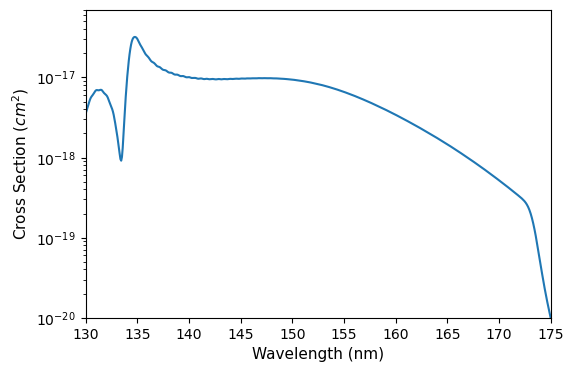

In [19]:
import duckdb

import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np   # (already imported earlier, but kept for completeness)
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
# Import both inset_axes and mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import pandas as pd
from multiprocessing import Pool, cpu_count
from functools import partial
import time


fig, ax = plt.subplots(figsize=(6, 4)) # This is the active line

ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=11)
# ax.set_title(f'Absorption Cross Section vs Wavelength (T = {T} K)') # Title is in the image, but not this code
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.7e-16)
ax.set_yscale('log')

# Plot model spectra for each alpha_D
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    ax.plot(1e7 / nu_range, cs, label=fr'Duo, $\alpha_D$ = {alpha_D} cm$^{{-1}}$', linestyle = "-")
    integrated_cs = np.trapz(cs, nu_range)
    print(f"Integrated cross-section for α_D={alpha_D}: {integrated_cs:.4e}")

# Validation data with error bars
ax.errorbar(validation_x, validation_y,
            yerr=0.3 * validation_y,
            fmt='o', markersize=4,markerfacecolor='none',
            color='black', label='Yoshino (2005)')
            
ax.plot(validation_x_2, validation_y_2,
            color='red', label='Exomol database', linestyle = "--")           

# Customize ticks
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(False)

# --- Set font size for legend ---
ax.legend(loc='lower left', fontsize=8
)


# ─────────────────────────────────────────────────────────────────
# --- NEW: Add Inset Plot (130-135 nm) ---
# ─────────────────────────────────────────────────────────────────

# 1. Define position: [x_start, y_start, width, height] in axes fraction
#    Placing it in the upper right, which is clear.
ax_inset = ax.inset_axes([0.25, 0.25, 0.23, 0.23])

# 2. Re-plot all data onto the inset
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    ax_inset.plot(1e7 / nu_range, cs, linestyle = "-")

ax_inset.errorbar(validation_x, validation_y,
                  yerr=0.3 * validation_y,
                  fmt='o', markersize=3, markerfacecolor='none', # smaller markers
                  color='black')
            
ax_inset.plot(validation_x_2, validation_y_2,
                  color='red', linestyle = "--")

# 3. Set the zoom limits for the inset
ax_inset.set_xlim(130, 135)
ax_inset.set_ylim(1e-19, 1e-16) # Zoom y-axis to the data in this region
ax_inset.set_yscale('log') # Match the main plot's y-scale

# 4. Style the inset (no labels, but with ticks)
ax_inset.set_xticklabels('')
ax_inset.set_yticklabels('')
ax_inset.tick_params(which='major', direction='in', top=True, right=True)
ax_inset.tick_params(which='minor', direction='in', top=True, right=True)
# Add a light grid to help guide the eye
ax_inset.grid(True, which='major', color='#DDDDDD', linestyle=':', linewidth=0.5)

# 5. Add connector lines to show where the zoom comes from
mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5")

# ─────────────────────────────────────────────────────────────────

# Use tight_layout to ensure labels don't overlap
plt.tight_layout()
# plt.savefig(f'o2_cross_section_comparison_T{T}_final.png', dpi=600)
plt.show()

In [31]:
alpha_D_list = [160]  # Example alpha_D values
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    
    
    
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    
    
    
    
    return np.array(cross_section_list)


results = []
cross_sections = []
start_time = time.time()
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K
T = 300  # Temperature in Kelvin
Q_300 = Q(T)



def get_polarizability (cross_section_list, nu_range, sensing_nu_list:list, gamma):
    """ The cross_section is in m²/molecule, nu_range is in cm⁻¹, sensing_nu_list is in cm⁻¹, gamma is in cm⁻¹
    This function computes the polarizability for each sensing frequency in sensing_nu_list.
    """


    K=1  # this constant is for converting the cross-section to a polarizability for this lower state but WITHOUT any populations built in

    c = 2.99792458e10  # speed of light in cm/s

    pol_list = []
    
    omega_sensing_list = [2 * np.pi * c * nu_sensing for nu_sensing in sensing_nu_list]  # Convert to angular frequency
    gamma = 2 * np.pi * c * gamma  # Convert gamma to angular frequency
    omega_range = 2 * np.pi * c * nu_range  # Convert nu_range to angular frequency

    for omega_sensing in omega_sensing_list:
        # Construct complex denominator

        denom = (omega_range - omega_sensing - 1j * gamma / 2) * (omega_range + omega_sensing + 1j * gamma / 2)

        # Compute integrand
        integrand = cross_section_list / denom

        # Perform numerical integration over nu_range
        alpha_i = K * np.trapz(integrand, omega_range)
        # Append the computed polarizability for this alpha_D
        pol_list.append(alpha_i)

    # Store the full complex result
    return pol_list




for idx, row in continuum_grouped.iterrows():
    
    
    if idx == continuum_grouped.index[0] or idx == continuum_grouped.index[-1]:
        print("First/Last row")
        print(f"Starting computation with {len((row.A)):,} transitions")
        print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
        print(f"Alpha_D values: {alpha_D_list}")
    
    

    # Extract quantum labels
    down_v = row['down_v']
    down_J = row['down_J']
    down_lambda = row['down_lambda']
    down_sigma = row['down_sigma']
    down_omega = row['down_omega']
    down_energy = row['down_energy']
    
    
    # Extract transition data
    A_list = np.array(row.A)
    linepos_list = np.array(row['line_pos']) 
    up_J = np.array(row['up_J'])
    
   


    not_an_intensity = A_list * (2 * up_J + 1) / (8.0 * np.pi*(c) * linepos_list**(2)*(2 * down_J + 1))
    
    
    # Compute cross section
    cross_section_byenergy_list = main(alpha_D_list, nu_range, linepos_list, not_an_intensity, 1)  # this function will return a cross_section as afunction of nu_range for each down_energy

    # Compute polarizability
    cross_section_byenergy_list_2 = cross_section_byenergy_list * 1e-4 # Convert to m²/molecule, useful for polarizability calculation


    sensing_list = [1e7/632.8, 1e7/532.0, 1e7/400, 1e7/388]  # Sensing wavenumber in cm⁻¹
    alpha_i_list = get_polarizability(cross_section_byenergy_list_2, nu_range, sensing_nu_list=sensing_list, gamma=4)



    # Store results
    #            Initialize result dict with standard fields. MAIN ENTRY 
    result_entry= {
        'down_v': down_v,
        'down_J': down_J,
        'down_lambda': down_lambda,
        'down_sigma': down_sigma,
        'down_omega': down_omega,
        'down_energy': down_energy,
        # 'cross_section': cross_section_byenergy_list
    }
    cross_section_entry= {
        'down_v': down_v,
        'down_J': down_J,
        'down_lambda': down_lambda,
        'down_sigma': down_sigma,
        'down_omega': down_omega,
        'down_energy': down_energy,
        'cross_section': cross_section_byenergy_list
    }

    for wl_inv_cm, alpha_i in zip(sensing_list, alpha_i_list):
        wl_nm = 1e7/wl_inv_cm
        result_entry[f'pol_{wl_nm:.1f}nm'] = alpha_i  # rounded for readability

    #Append the the master results list for this lower energy level
    results.append(result_entry)
    cross_sections.append(cross_section_entry)

total_time = time.time() - start_time
print(f"\nTotal computation time: {total_time:.2f}s")
print(f"Cross-section shapes: {[cs.shape for cs in cross_section_byenergy_list]}")

First/Last row
Starting computation with 388 transitions
Frequency range: 50000.0 to 90909.1 cm⁻¹
Alpha_D values: [160]
First/Last row
Starting computation with 1,210 transitions
Frequency range: 50000.0 to 90909.1 cm⁻¹
Alpha_D values: [160]

Total computation time: 170.46s
Cross-section shapes: [(1000,)]


In [33]:
results[0:4]


[{'down_v': 0,
  'down_J': 0.0,
  'down_lambda': 0.0,
  'down_sigma': 0.0,
  'down_omega': 0.0,
  'down_energy': 2.8652,
  'pol_632.8nm': array([1.65875848e-38+2.30951285e-43j]),
  'pol_532.0nm': array([1.69751104e-38+2.87948982e-43j]),
  'pol_400.0nm': array([1.80849893e-38+4.35843063e-43j]),
  'pol_388.0nm': array([1.82577626e-38+4.58146432e-43j])},
 {'down_v': 0,
  'down_J': 1.0,
  'down_lambda': 0.0,
  'down_sigma': 1.0,
  'down_omega': 1.0,
  'down_energy': 2.8652,
  'pol_632.8nm': array([1.65875848e-38+2.30951285e-43j]),
  'pol_532.0nm': array([1.69751104e-38+2.87948982e-43j]),
  'pol_400.0nm': array([1.80849893e-38+4.35843063e-43j]),
  'pol_388.0nm': array([1.82577626e-38+4.58146432e-43j])},
 {'down_v': 0,
  'down_J': 2.0,
  'down_lambda': 0.0,
  'down_sigma': 0.0,
  'down_omega': 0.0,
  'down_energy': 17.1904,
  'pol_632.8nm': array([1.65893504e-38+2.31013039e-43j]),
  'pol_532.0nm': array([1.69769812e-38+2.88028427e-43j]),
  'pol_400.0nm': array([1.808718e-38+4.35974128e-43j])

In [56]:
# cross_sections[0:4]
# import pandas as pd
# import numpy as np

# # Assuming 'cross_sections_list' is your list of dictionaries
# df_cs = pd.DataFrame(cross_sections)

# # 1. Convert arrays to standard lists for safe Parquet serialization
# df_cs['cross_section'] = df_cs['cross_section'].apply(lambda x: np.array(x).flatten().tolist())

# # 2. Write to Parquet (Requires 'pyarrow' installed: pip install pyarrow)
# file_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/cross_sections.parquet'
# df_cs.to_parquet(file_path, engine='pyarrow')
# print("Successfully saved to Parquet.")

# # ---------------------------------------------------------


Successfully saved to Parquet.


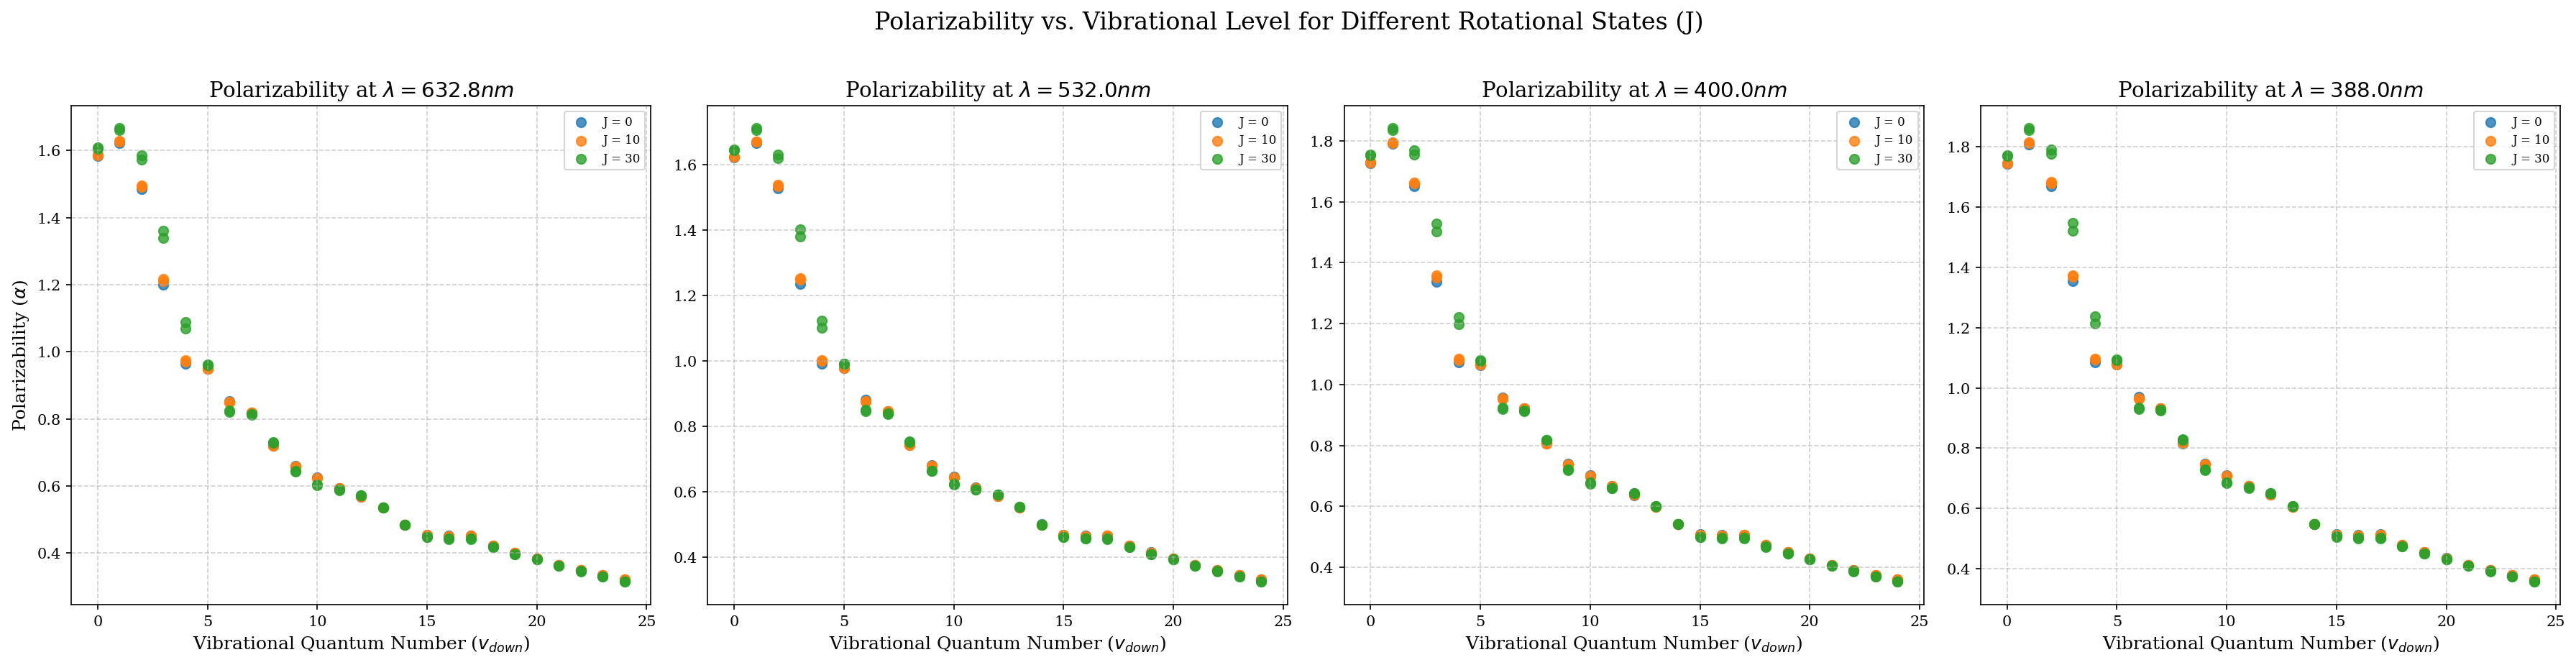

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Constants and Parameters ---
# Multiplier from your snippet: (1e30 * 3e8 / np.pi)
# Note: 3e8 is approx speed of light, 1e30 converts units (likely to cubic Angstroms or similar)
MULTIPLIER = (1e30 * 3e8) / np.pi

# The specific keys we want to plot (Wavelengths)
wavelength_keys = ['pol_632.8nm', 'pol_532.0nm', 'pol_400.0nm', 'pol_388.0nm']

# The specific rotational levels we want to compare
target_Js = [0, 10, 30]

# --- 2. Setup the Plotting Environment ---
# Create 1 row, 4 columns
fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=False)

# Loop through each wavelength (each subplot)
for i, pol_key in enumerate(wavelength_keys):
    ax = axes[i]
    
    # Loop through the requested J levels (each series in the scatter plot)
    for target_J in target_Js:
        
        v_list = []
        alpha_list = []
        
        # --- 3. Iterate through results to find matches ---
        for r in results:
            # Check if this entry matches our target J
            # Using np.isclose in case of float precision issues, though == usually works
            if np.isclose(r['down_J'], target_J):
                
                # Get vibrational level
                v = r['down_v']
                
                # Get the complex polarizability array for this wavelength
                # It is a 1-element array, so we take [0]
                pol_complex = r[pol_key][0]
                
                # Apply Multiplier and take REAL part
                alpha_real = (pol_complex * MULTIPLIER).real
                
                v_list.append(v)
                alpha_list.append(alpha_real)
        
        # --- 4. Plot this Series ---
        if v_list:
            ax.scatter(v_list, alpha_list, label=f'J = {target_J}', s=40, alpha=0.8)
    
    # --- 5. Formatting the Subplot ---
    # Extract numeric wavelength for title (e.g., "633.0nm")
    wv_label = pol_key.replace("pol_", "")
    
    ax.set_title(f'Polarizability at $\lambda = {wv_label}$', fontsize=14)
    ax.set_xlabel('Vibrational Quantum Number ($v_{down}$)', fontsize=12)
    
    # Only put Y-label on first plot to reduce clutter
    if i == 0:
        ax.set_ylabel(r'Polarizability ($\alpha$)', fontsize=12)
        
    ax.grid(True, linestyle='--', alpha=0.6, which = 'major')
    ax.legend()

# --- 6. Final Layout Adjustments ---
plt.suptitle('Polarizability vs. Vibrational Level for Different Rotational States (J)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

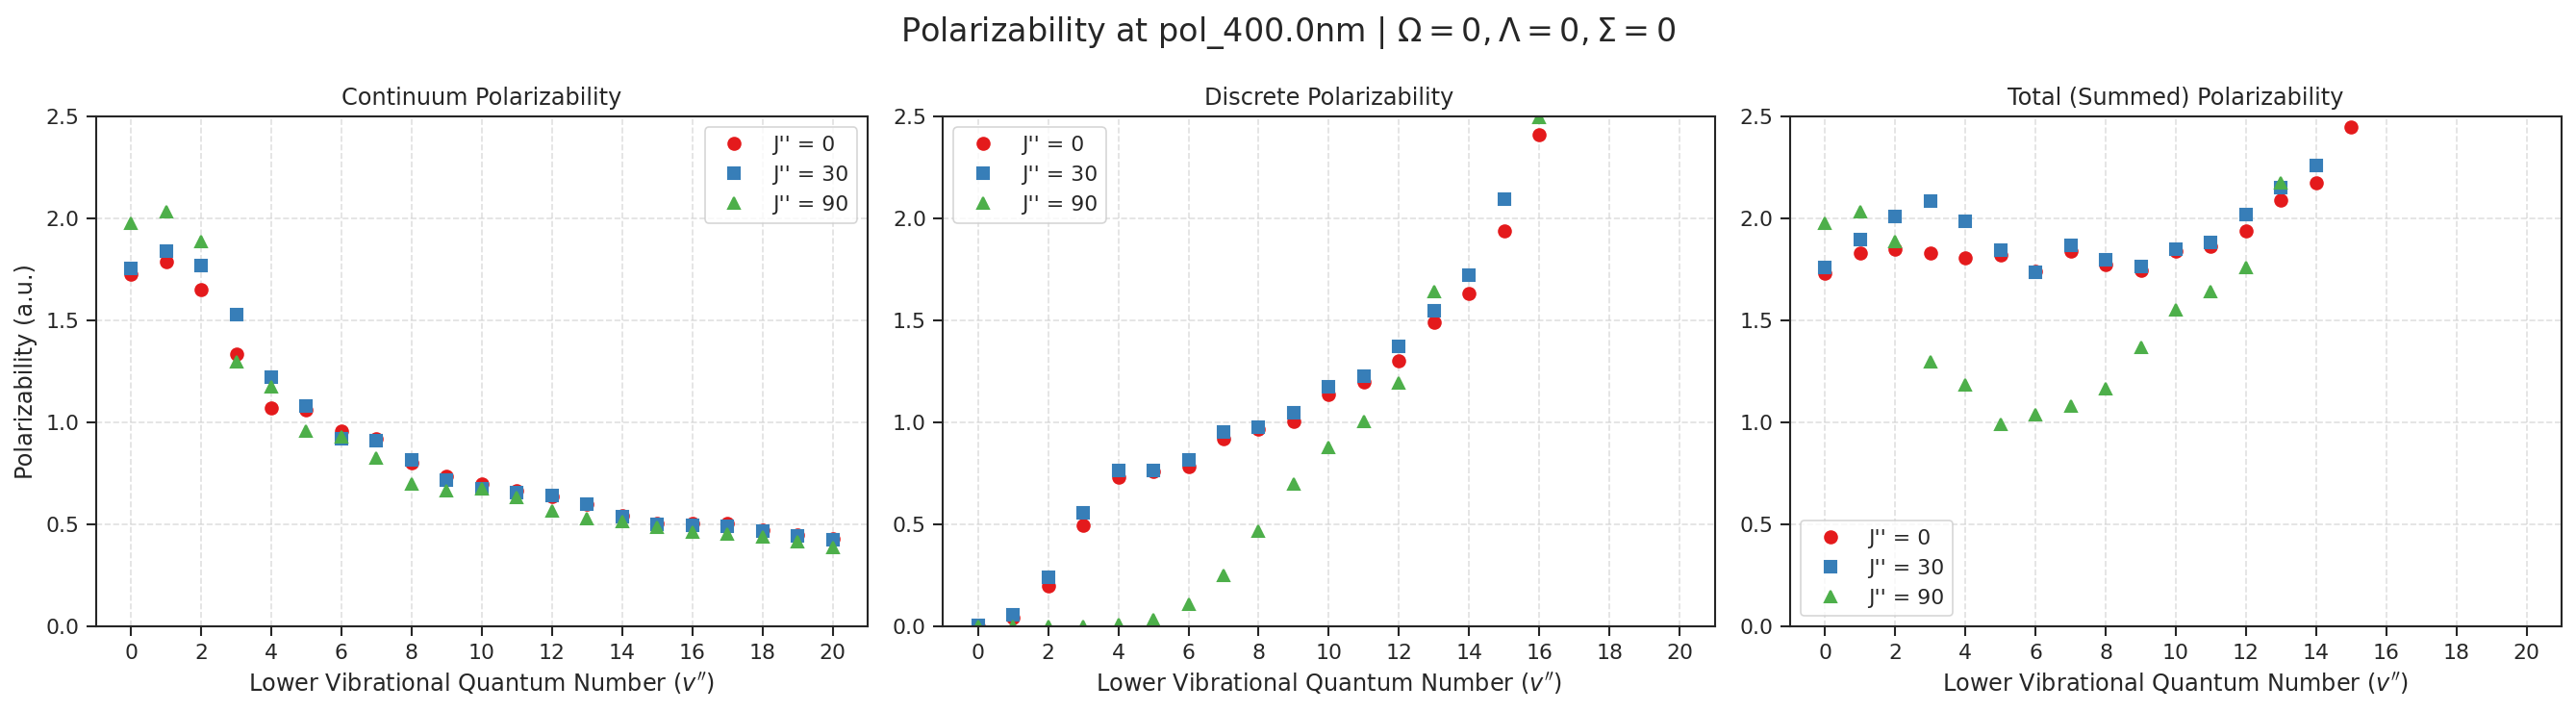

In [47]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Parameters & Database Configuration
# ==========================================
DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
WAVELENGTH_COL = '"pol_400.0nm"'  # Target column (note the double quotes for SQL)
MAX_V = 20
J_VALUES = [0, 30, 90]

# Fixed quantum numbers for Omega, Lambda, Sigma
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# SQL Query using DuckDB
# ==========================================
# We join the tables on all matching quantum numbers to perfectly align 
# the continuum and discrete values, summing them directly in SQL.
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.{WAVELENGTH_COL} AS pol_cont,
    d.{WAVELENGTH_COL} AS pol_disc,
    (COALESCE(c.{WAVELENGTH_COL}, 0) + COALESCE(d.{WAVELENGTH_COL}, 0)) AS pol_total
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d 
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_J IN ({','.join(map(str, J_VALUES))})
    AND c.down_v <= {MAX_V}
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_J, c.down_v
"""

# Connect to DB and fetch data
with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# ==========================================
# Plotting
# ==========================================
# Set up high-quality publication-ready styling
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
# Clean up the wavelength string for the title (removes the SQL double quotes)
clean_wavelength = WAVELENGTH_COL.strip('"')

fig.suptitle(fr'Polarizability at {clean_wavelength} | $\Omega={FIXED_OMEGA}, \Lambda={FIXED_LAMBDA}, \Sigma={FIXED_SIGMA}$', fontsize=16)

colors = sns.color_palette("Set1", n_colors=len(J_VALUES))
markers = ['o', 's', '^']

# Subplot 1: Continuum Only
for i, j_val in enumerate(J_VALUES):
    subset = df[df['down_J'] == j_val]
    axes[0].plot(subset['down_v'], subset['pol_cont'], marker=markers[i], color=colors[i], 
                 linestyle='none', markersize=6, label=f"J'' = {j_val}")
axes[0].set_title('Continuum Polarizability')
axes[0].set_ylabel('Polarizability (a.u.)')

# Subplot 2: Discrete Only
for i, j_val in enumerate(J_VALUES):
    subset = df[df['down_J'] == j_val]
    axes[1].plot(subset['down_v'], subset['pol_disc'], marker=markers[i], color=colors[i], 
                 linestyle='none', markersize=6, label=f"J'' = {j_val}")
axes[1].set_title('Discrete Polarizability')

# Subplot 3: Summed (Total)
for i, j_val in enumerate(J_VALUES):
    subset = df[df['down_J'] == j_val]
    axes[2].plot(subset['down_v'], subset['pol_total'], marker=markers[i], color=colors[i], 
                 linestyle='none', markersize=6, label=f"J'' = {j_val}")
axes[2].set_title('Total (Summed) Polarizability')

# Apply unified styling to all axes
for ax in axes:
    ax.set_xlabel("Lower Vibrational Quantum Number ($v''$)")
    ax.set_xticks(range(0, MAX_V + 1, 2)) # Adjust x-ticks to show even numbers up to 20
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(frameon=True)
    ax.set_ylim(0,2.5)

plt.tight_layout()
plt.show()

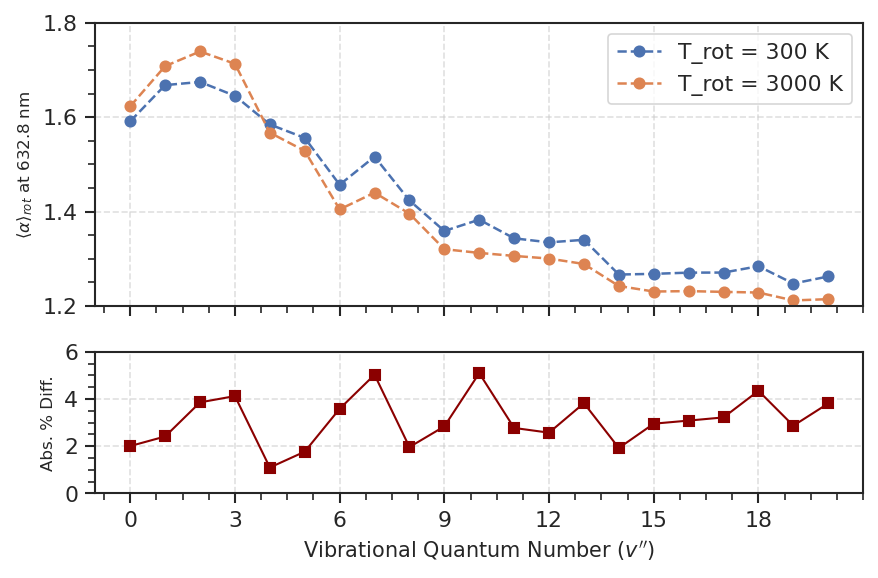

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Constants and Parameters
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125

# Rotational temperatures to apply inside each v-band
TARGET_TEMPS = [300, 3000]

DB_PATH = 'polarizabilities.duckdb'
TARGET_WAVELENGTH = '"pol_632.8nm"'
DF_COL_NAME = 'pol_632_8nm'

# Fixed quantum numbers
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# 2. Database IO (DuckDB)
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    (COALESCE(c.{TARGET_WAVELENGTH}, 0) + COALESCE(d.{TARGET_WAVELENGTH}, 0)) AS {DF_COL_NAME}
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_v <= {MAX_V}
    AND c.down_J <= {MAX_J}
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# Normalize energy to the global minimum to prevent exponent overflow
df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY
# ==========================================
# 3. Rotational Boltzmann Averaging per v-level
# ==========================================
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Create a 2x1 grid, making the top plot twice as tall as the bottom plot
fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Dictionary to store the averaged values for difference calculation later
avg_pol_results = {}

for T in TARGET_TEMPS:
    # 1. Calculate the rotational Boltzmann weight
    exponent = (-h * c * df['delta_E']) / (k_B * T)
    df['weight'] = (2 * df['down_J'] + 1) * np.exp(exponent)
    
    # 2. Multiply polarizability by weight
    df['weighted_pol'] = df['weight'] * df[DF_COL_NAME]
    
    # 3. Group by v and calculate the weighted average for that specific band
    grouped = df.groupby('down_v').agg(
        sum_weighted_pol=('weighted_pol', 'sum'),
        sum_weights=('weight', 'sum')
    ).reset_index()
    
    grouped['avg_pol'] = np.where(
        grouped['sum_weights'] > 0, 
        grouped['sum_weighted_pol'] / grouped['sum_weights'], 
        0.0
    )
    
    # Store results for the % difference subplot
    avg_pol_results[T] = grouped['avg_pol'].values
    v_levels = grouped['down_v'].values # Assuming v_levels are identical for both loops
    
    # 4. Plot the main results (Top Subplot)
    axes[0].plot(grouped['down_v'], grouped['avg_pol'], marker='o', linestyle='--', 
                 label=f"T_rot = {T} K")

# --- Formatting Subplot 1 (Absolute Values) ---
wv_label = TARGET_WAVELENGTH.strip('"').replace("pol_", "")
# axes[0].set_title(f"Rotationally Averaged Polarizability at {wv_label}", fontsize=14)
axes[0].set_ylabel(r"$\langle\alpha\rangle_{rot}$ at 632.8 nm", fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim(1.2,1.8)
axes[0].minorticks_on()
axes[0].legend(frameon=True)

# ==========================================
# 4. Calculate and Plot Percentage Difference
# ==========================================
# Calculate absolute percentage difference relative to 300 K
# Formula: |(Value_3000K - Value_300K) / Value_300K| * 100
abs_diff_pct = np.abs(avg_pol_results[3000] - avg_pol_results[300]) / np.abs(avg_pol_results[300]) * 100

# Plot on the bottom subplot
axes[1].plot(v_levels, abs_diff_pct, marker='s', color='darkred', linestyle='-', linewidth=1)

# --- Formatting Subplot 2 (% Difference) ---
axes[1].set_ylabel("Abs. % Diff.", fontsize=8)
axes[1].set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=10)
axes[1].set_xticks(range(0, MAX_V + 1, 3))
axes[1].set_ylim(0, 6)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].minorticks_on()
# Final Layout Adjustments
# plt.suptitle(f"Thermal Effects on Polarizability | J $\leq$ {MAX_J}", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('rot_pol.pdf', dpi=500)
plt.show()

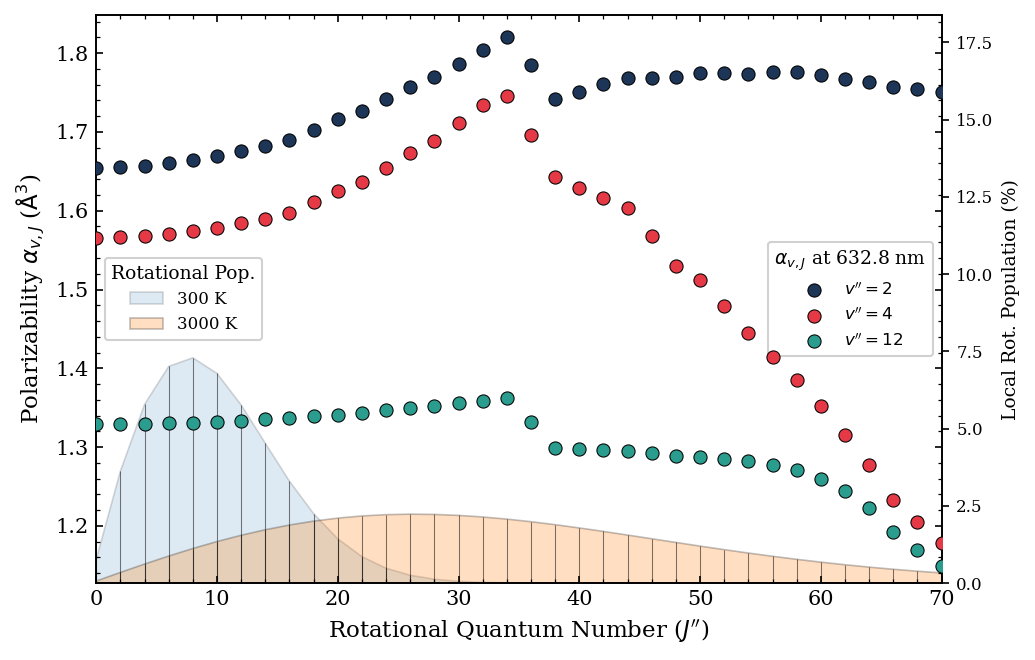

In [17]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator

# --- Dissertation-Grade Plot Styling ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "figure.dpi": 150,
    "grid.alpha": 0.2,
    "legend.frameon": True,
    "legend.fontsize": 8
})

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
c, h, k_B = 2.99792458e10, 6.62607015e-34, 1.380649e-23
GLOBAL_MIN_ENERGY = 2.8739
MAX_V, MAX_J, MAX_J_PLOT = 20, 125, 70
TARGET_TEMPS = [300, 3000]
DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
TARGET_WL = '"pol_632.8nm"'
TARGET_V = [2, 4, 12]
POP_REF_V = 2  # Qualitative reference level for the background stems

query = f"""
SELECT
    c.down_v, c.down_J, c.down_energy,
    (COALESCE(c.{TARGET_WL}, 0) + COALESCE(d.{TARGET_WL}, 0)) AS total_alpha
FROM cont_polarizabilities c
JOIN discrete_polarizabilities d
    ON c.down_v = d.down_v AND c.down_J = d.down_J
    AND c.down_omega = 0 AND c.down_lambda = 0 AND c.down_sigma = 0
WHERE c.down_v <= {MAX_V} AND c.down_J <= {MAX_J} and  c.down_lambda = 0 AND c.down_sigma = 0 
ORDER BY c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# ==========================================
# 2. Local Rotational Normalization
# ==========================================
df['E_v0'] = df.groupby('down_v')['down_energy'].transform('min')
df['E_rot_local'] = df['down_energy'] - df['E_v0']

for T in TARGET_TEMPS:
    exponent = (-h * c * df['E_rot_local']) / (k_B * T)
    df[f'weight_{T}K'] = (2 * df['down_J'] + 1) * np.exp(exponent)
    group_sum = df.groupby('down_v')[f'weight_{T}K'].transform('sum')
    df[f'pop_local_{T}K'] = (df[f'weight_{T}K'] / group_sum) * 100.0

df_plot = df[df['down_v'].isin(TARGET_V) & (df['down_J'] <= MAX_J_PLOT)].copy()

# ==========================================
# 3. Visual Style (Navy, Red, Teal)
# ==========================================
v_colors = {
    2:  '#1D3557',   # dark navy
    4:  '#E63946',   # red
    12: '#2A9D8F',   # teal
}

# Match temperature shading colors with previous cell
temp_shade_colors = {
    300: '#1f77b4',   # blue
    3000: '#ff7f0e',  # orange
}

# ==========================================
# 4. Plotting
# ==========================================
fig, ax_alpha = plt.subplots(figsize=(7, 4.5))
ax_pop = ax_alpha.twinx()

# --- Population Stems + Shaded Fill (Qualitative Background from v=4) ---
vd_pop = df[df['down_v'] == POP_REF_V]
for T in TARGET_TEMPS:
    J   = vd_pop['down_J'].values
    pop = vd_pop[f'pop_local_{T}K'].values
    
    is_hot = (T == 3000)
    alpha_val = 0.25 if is_hot else 0.15
    shade_color = temp_shade_colors.get(T, 'gray')
    
    # Shaded fill with solid black border for both temperatures
    ax_pop.fill_between(
        J, 0, pop,
        color=shade_color,
        alpha=alpha_val,
        edgecolor='black',
        linewidth=0.8,
        linestyle='solid'
    )
    
    # Vertical Stems (The requested vertical lines)
    ax_pop.vlines(J, 0, pop, color='black', linewidth=0.5, alpha=0.3)

# --- Polarizability Curves (Dashed lines using specific palette) ---
for v_val in TARGET_V:
    vd = df_plot[df_plot['down_v'] == v_val]
    # before plotting make sure each series is unique in its Y values to avoid overplotting issues
    vd = vd.drop_duplicates(subset=['down_J'], keep='first')

    ax_alpha.scatter(vd['down_J'], vd['total_alpha'],
                     label=f"$v'' = {v_val}$",
                     color=v_colors[v_val],
                     edgecolor='black', linewidth=0.5, s=40, zorder=20)
    # ax_alpha.plot(vd['down_J'], vd['total_alpha'],
    #               label=r"$v'' = " + str(v_val) + "$",
    #               color=v_colors[v_val],
    #               linestyle='--', linewidth=2.0, zorder=10)

# ==========================================
# 5. Formatting
# ==========================================
ax_alpha.set_xlim(0, MAX_J_PLOT)
ax_alpha.set_ylim(df_plot['total_alpha'].min() * 0.995, 
                  df_plot['total_alpha'].max() * 1.015)
ax_alpha.set_xlabel(r"Rotational Quantum Number ($J''$)", fontsize=11)
ax_alpha.set_ylabel(r"Polarizability $\alpha_{v,J}$ ($\mathrm{\AA}^3$)", fontsize=11)

# Push population to background
ax_alpha.set_zorder(ax_pop.get_zorder() + 1)
ax_alpha.patch.set_visible(False)

# Qualitative Pop Axis
ax_pop.set_ylim(0, df[f'pop_local_300K'].max() * 2.5)
ax_pop.set_ylabel("Local Rot. Population (%)", fontsize=9, color='black')
ax_pop.tick_params(axis='y', colors='black', labelsize=8)

ax_alpha.xaxis.set_minor_locator(AutoMinorLocator())
ax_alpha.yaxis.set_minor_locator(AutoMinorLocator())
ax_alpha.tick_params(which='both', direction='in', top=True, right=True)
ax_alpha.grid(False)

# ==========================================
# 6. Legends
# ==========================================
# Alpha Legend
leg1 = ax_alpha.legend(loc='center right', title=r"$\alpha_{v,J}$ at 632.8 nm", 
                       title_fontsize=9, framealpha=0.9)
ax_alpha.add_artist(leg1)

# Population Legend
pop_handles = [
    mpatches.Patch(facecolor=temp_shade_colors[300], edgecolor='black', linewidth=0.8, alpha=0.15, label="300 K"),
    mpatches.Patch(facecolor=temp_shade_colors[3000], edgecolor='black', linewidth=0.8, alpha=0.25, label="3000 K")
]
ax_alpha.legend(handles=pop_handles, loc='center left', title="Rotational Pop.", 
                title_fontsize=9, framealpha=0.9)

plt.tight_layout()
# print(sum(vd_pop[f'pop_local_300K']))  # Print total population for v=2 at 300K to verify it sums to 100%
plt.savefig('alpha_vs_J.pdf', dpi=400)
plt.show()

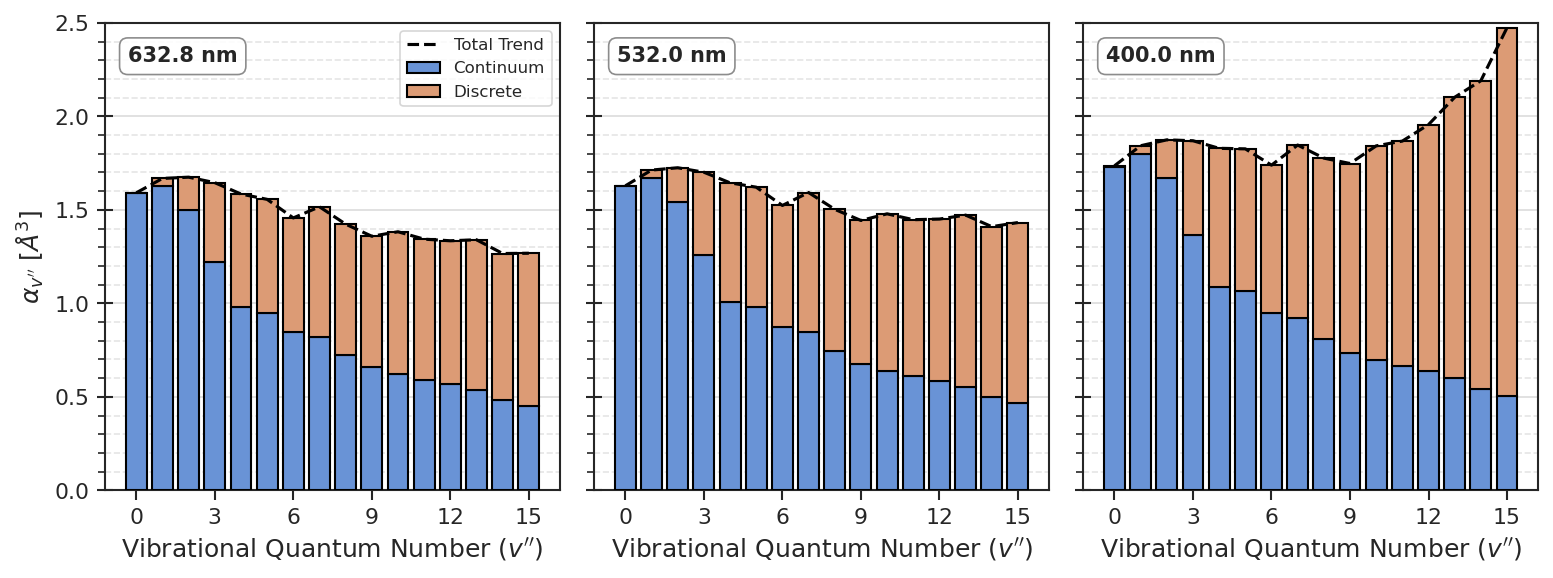

In [76]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Constants and Parameters
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 15              # Restrict x-axis to 15
MAX_J = 125
T_ROT = 300  # Fixed rotational temperature

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# Fixed quantum numbers
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# 2. Database IO (DuckDB)
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    COALESCE(c."pol_400.0nm", 0) AS cont_400_0nm,
    COALESCE(d."pol_400.0nm", 0) AS disc_400_0nm,
    COALESCE(c."pol_532.0nm", 0) AS cont_532_0nm,
    COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
    COALESCE(c."pol_632.8nm", 0) AS cont_632_8nm,
    COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_v <= {MAX_V}
    AND c.down_J <= {MAX_J}
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# Normalize energy
df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY

# ==========================================
# 3. Rotational Boltzmann Averaging per v-level
# ==========================================
exponent = (-h * c * df['delta_E']) / (k_B * T_ROT)
df['weight'] = (2 * df['down_J'] + 1) * np.exp(exponent)

# Added 400.0 nm to wavelengths loop
wavelengths = ['400_0nm', '532_0nm', '632_8nm']

for wl in wavelengths:
    df[f'w_cont_{wl}'] = df['weight'] * df[f'cont_{wl}']
    df[f'w_disc_{wl}'] = df['weight'] * df[f'disc_{wl}']

agg_dict = {'weight': 'sum'}
for wl in wavelengths:
    agg_dict[f'w_cont_{wl}'] = 'sum'
    agg_dict[f'w_disc_{wl}'] = 'sum'

grouped = df.groupby('down_v').agg(agg_dict).reset_index()

for wl in wavelengths:
    grouped[f'avg_cont_{wl}'] = np.where(grouped['weight'] > 0, grouped[f'w_cont_{wl}'] / grouped['weight'], 0.0)
    grouped[f'avg_disc_{wl}'] = np.where(grouped['weight'] > 0, grouped[f'w_disc_{wl}'] / grouped['weight'], 0.0)

# ==========================================
# 4. Plotting: Stacked Bar Charts + Trendline
# ==========================================
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Adjusted for 3 plots, widened figure slightly
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4), sharey=True)

# Explicitly ordered left to right: 632.8 -> 532.0 -> 400.0
plot_config = [
    ('632_8nm', '632.8 nm'),
    ('532_0nm', '532.0 nm'),
    ('400_0nm', '400.0 nm')
]

cont_color = "#6993D6"  
disc_color = "#DC9B75"  

for i, (col_key, label) in enumerate(plot_config):
    ax = axes[i]
    v_levels = grouped['down_v']
    cont_vals = grouped[f'avg_cont_{col_key}']
    disc_vals = grouped[f'avg_disc_{col_key}']
    
    # Calculate total for the trendline
    total_vals = cont_vals + disc_vals
    
    # Plot Stacked Bars
    ax.bar(v_levels, cont_vals, label='Continuum', color=cont_color, edgecolor='black', linewidth=1, zorder=3)
    ax.bar(v_levels, disc_vals, bottom=cont_vals, label='Discrete', color=disc_color, edgecolor='black', linewidth=1, zorder=3)

    # Plot Trendline (Removed the marker 'o')
    ax.plot(v_levels, total_vals, color='black', linestyle='--', 
            linewidth=1.5, label='Total Trend', zorder=5)

    # --- Formatting ---
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=10, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9), zorder=6)

    ax.set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=12)
    # Ticks adjusted for max 15 cleanly
    ax.set_xticks(range(0, MAX_V + 1, 3))
    ax.set_ylim(0, 2.5)
    
    # Tick Control
    ax.minorticks_on()
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    # Make major Y ticks cross ('inout')
    ax.tick_params(axis='y', which='major', direction='inout', length=8, width=1)
    
    # Grid Control
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.7, zorder=0) 
    ax.grid(True, which='minor', axis='y', linestyle='--', alpha=0.5, zorder=0) 
    ax.grid(False, axis='x') 
    
    if i == 0:
        ax.set_ylabel(r"$\alpha_{v''}$ [$\AA^3$]", fontsize=12)
        # Legend will now automatically include the 'Total Trend' line
        ax.legend(frameon=True, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('dis_con_pol.pdf', dpi=400)
plt.show()

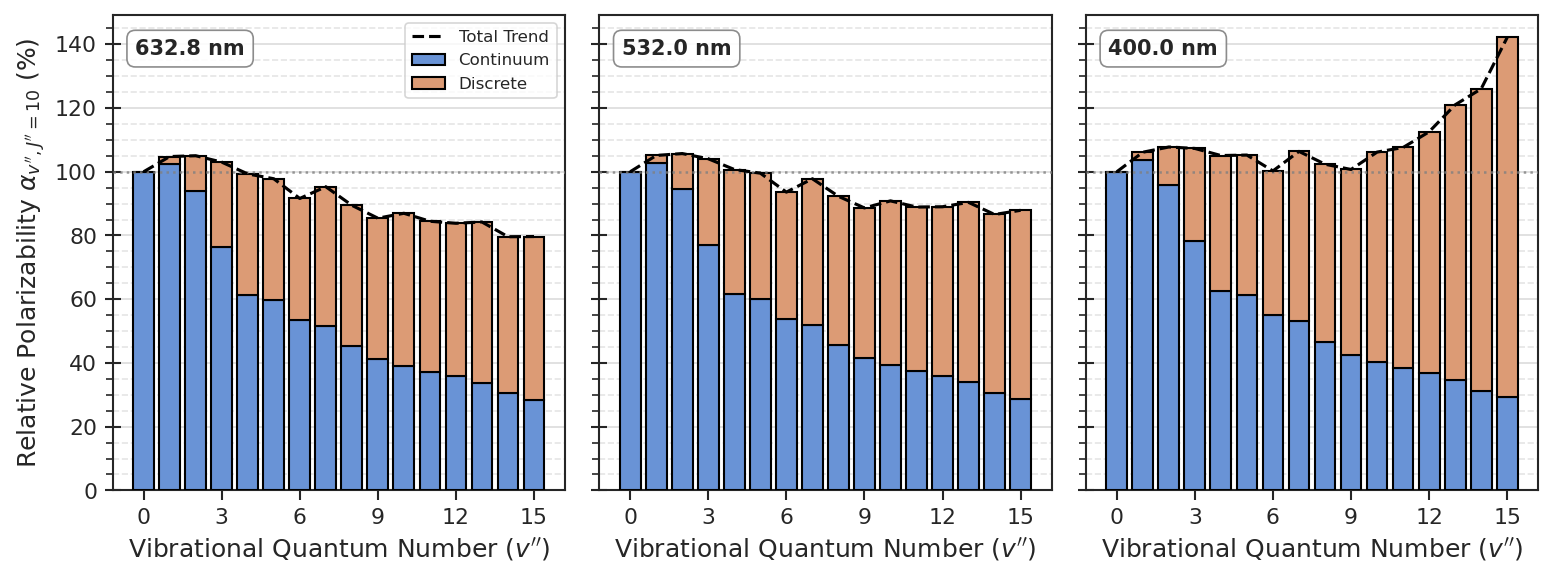

In [56]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Constants and Parameters
# ==========================================
MAX_V = 15              # Restrict x-axis to 15
FIXED_J = 10            # Evaluate a specific rotational level

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# Fixed quantum numbers
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# 2. Database IO (DuckDB)
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    COALESCE(c."pol_400.0nm", 0) AS cont_400_0nm,
    COALESCE(d."pol_400.0nm", 0) AS disc_400_0nm,
    COALESCE(c."pol_532.0nm", 0) AS cont_532_0nm,
    COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
    COALESCE(c."pol_632.8nm", 0) AS cont_632_8nm,
    COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_v <= {MAX_V}
    AND c.down_J = {FIXED_J}   -- Filter directly for J=10
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_v
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# ==========================================
# 3. Calculate Percentage Relative to v=0
# ==========================================
wavelengths = ['400_0nm', '532_0nm', '632_8nm']

for wl in wavelengths:
    # Total polarizability for this specific J level
    total_pol = df[f'cont_{wl}'] + df[f'disc_{wl}']
    
    # Extract the v=0 total value to use as the 100% baseline
    v0_total = total_pol[df['down_v'] == 0].values[0]
    
    # Calculate percentages
    df[f'pct_cont_{wl}'] = (df[f'cont_{wl}'] / v0_total) * 100
    df[f'pct_disc_{wl}'] = (df[f'disc_{wl}'] / v0_total) * 100
    df[f'pct_total_{wl}'] = (total_pol / v0_total) * 100

# ==========================================
# 4. Plotting: Stacked Bar Charts + Trendline
# ==========================================
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4), sharey=True)

# Explicitly ordered left to right: 632.8 -> 532.0 -> 400.0
plot_config = [
    ('632_8nm', '632.8 nm'),
    ('532_0nm', '532.0 nm'),
    ('400_0nm', '400.0 nm')
]

cont_color = "#6993D6"  
disc_color = "#DC9B75"  

for i, (col_key, label) in enumerate(plot_config):
    ax = axes[i]
    v_levels = df['down_v']
    
    # Using the new percentage columns for the plot
    cont_vals = df[f'pct_cont_{col_key}']
    disc_vals = df[f'pct_disc_{col_key}']
    total_vals = df[f'pct_total_{col_key}']
    
    # Plot Stacked Bars (now in percentage scale)
    ax.bar(v_levels, cont_vals, label='Continuum', color=cont_color, edgecolor='black', linewidth=1, zorder=3)
    ax.bar(v_levels, disc_vals, bottom=cont_vals, label='Discrete', color=disc_color, edgecolor='black', linewidth=1, zorder=3)

    # Plot Trendline (Removed the marker 'o')
    ax.plot(v_levels, total_vals, color='black', linestyle='--', 
            linewidth=1.5, label='Total Trend', zorder=5)
            
    # Add a subtle reference line at exactly 100% (the v=0 baseline)
    ax.axhline(100, color='gray', linestyle=':', linewidth=1.2, alpha=0.8, zorder=4)

    # --- Formatting ---
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=10, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9), zorder=6)

    ax.set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=12)
    ax.set_xticks(range(0, MAX_V + 1, 3))
    
    # Tick Control
    ax.minorticks_on()
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    # Make major Y ticks cross ('inout')
    ax.tick_params(axis='y', which='major', direction='inout', length=8, width=1)
    
    # Grid Control
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.7, zorder=0) 
    ax.grid(True, which='minor', axis='y', linestyle='--', alpha=0.5, zorder=0) 
    ax.grid(False, axis='x') 
    
    if i == 0:
        # Changed ylabel to reflect single J state logic
        ax.set_ylabel(rf"Relative Polarizability $\alpha_{{v'', J''={FIXED_J}}}$ (%)", fontsize=12)
        ax.legend(frameon=True, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('dis_con_pol_j10.png', dpi=400)
plt.show()

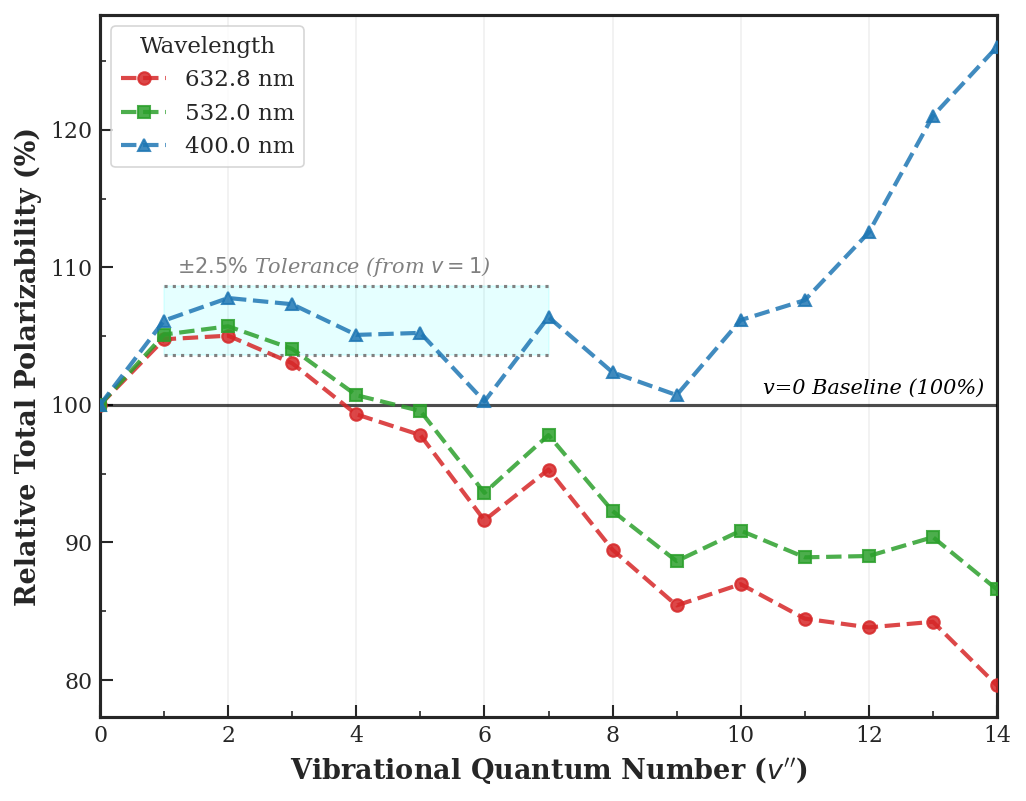

In [67]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. Constants and Parameters
# ==========================================
MAX_V = 14              # Restrict x-axis to 14
FIXED_J = 10            # Evaluate a specific rotational level

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# Fixed quantum numbers
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# 2. Database IO (DuckDB)
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    COALESCE(c."pol_400.0nm", 0) AS cont_400_0nm,
    COALESCE(d."pol_400.0nm", 0) AS disc_400_0nm,
    COALESCE(c."pol_532.0nm", 0) AS cont_532_0nm,
    COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
    COALESCE(c."pol_632.8nm", 0) AS cont_632_8nm,
    COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_v <= {MAX_V}
    AND c.down_J = {FIXED_J}
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_v
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# ==========================================
# 3. Calculate Total Percentage Relative to v=0
# ==========================================
wavelengths = ['632_8nm', '532_0nm', '400_0nm']

for wl in wavelengths:
    # Calculate Total (Discrete + Continuum)
    df[f'total_{wl}'] = df[f'cont_{wl}'] + df[f'disc_{wl}']
    
    # Extract the v=0 baseline
    v0_total = df.loc[df['down_v'] == 0, f'total_{wl}'].values[0]
    
    # Normalize to percentage
    df[f'pct_total_{wl}'] = (df[f'total_{wl}'] / v0_total) * 100

# ==========================================
# 4. Plotting: 3 Lines on a Single Axes
# ==========================================
# Nature-style configuration
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

fig, ax = plt.subplots(figsize=(7, 5.5))

# Plot Configurations
plot_config = {
    '632_8nm': {'label': '632.8 nm', 'color': '#d62728', 'marker': 'o'},  # Red
    '532_0nm': {'label': '532.0 nm', 'color': '#2ca02c', 'marker': 's'},  # Green
    '400_0nm': {'label': '400.0 nm', 'color': '#1f77b4', 'marker': '^'}   # Blue
}

v_levels = df['down_v']

# Plot the 3 wavelength lines
for wl in wavelengths:
    cfg = plot_config[wl]
    ax.plot(v_levels, df[f'pct_total_{wl}'], 
            label=cfg['label'], 
            color=cfg['color'], 
            marker=cfg['marker'], 
            ls='--', 
            markersize=6, 
            linewidth=2, 
            alpha=0.85,
            zorder=5)

# --- Add Reference Features ---
ax.axhline(100, color='black', linestyle='-', linewidth=1.5, alpha=0.7, zorder=3)
ax.text(MAX_V - 0.2, 100.5, "v=0 Baseline (100%)", ha='right', va='bottom', fontsize=10, style='italic', color='black')

# ---------------------------------------------------------
# NEW: Tolerance Band centered at the v=1 value for 400.0 nm
# ---------------------------------------------------------
# Extract the exact y-value at v=1 for 400.0 nm
v1_val_400 = df.loc[df['down_v'] == 1, 'pct_total_400_0nm'].values[0]

tol = 2.5
upper_bound = v1_val_400 + tol
lower_bound = v1_val_400 - tol

ax.hlines(upper_bound, xmin=1, xmax=7, colors='gray', linestyles=':', linewidth=1.5, zorder=2)
ax.hlines(lower_bound, xmin=1, xmax=7, colors='gray', linestyles=':', linewidth=1.5, zorder=2)

# Shade the tolerance region
ax.fill_betweenx([lower_bound, upper_bound], x1=1, x2=7, color='cyan', alpha=0.1, zorder=1)
ax.text(1.2, upper_bound + 0.5, r"$\pm 2.5\%$ Tolerance (from $v=1$)", ha='left', va='bottom', fontsize=10, color='gray', style='italic')

# --- Formatting ---
ax.set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=13, fontweight='bold')
ax.set_ylabel(r"Relative Total Polarizability (%)", fontsize=13, fontweight='bold')

ax.set_xticks(range(0, MAX_V + 1, 2))
ax.set_xlim(0,14)

# Adjust Y-limits if necessary
current_ylim = ax.get_ylim()
if current_ylim[1] < upper_bound + 2:
    ax.set_ylim(current_ylim[0], upper_bound + 2)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.3, zorder=0)

ax.legend(frameon=True, loc='best', fontsize=11, title="Wavelength", title_fontsize=11)

plt.tight_layout()
plt.savefig('total_pol_v_dependence.pdf', dpi=400)
plt.show()

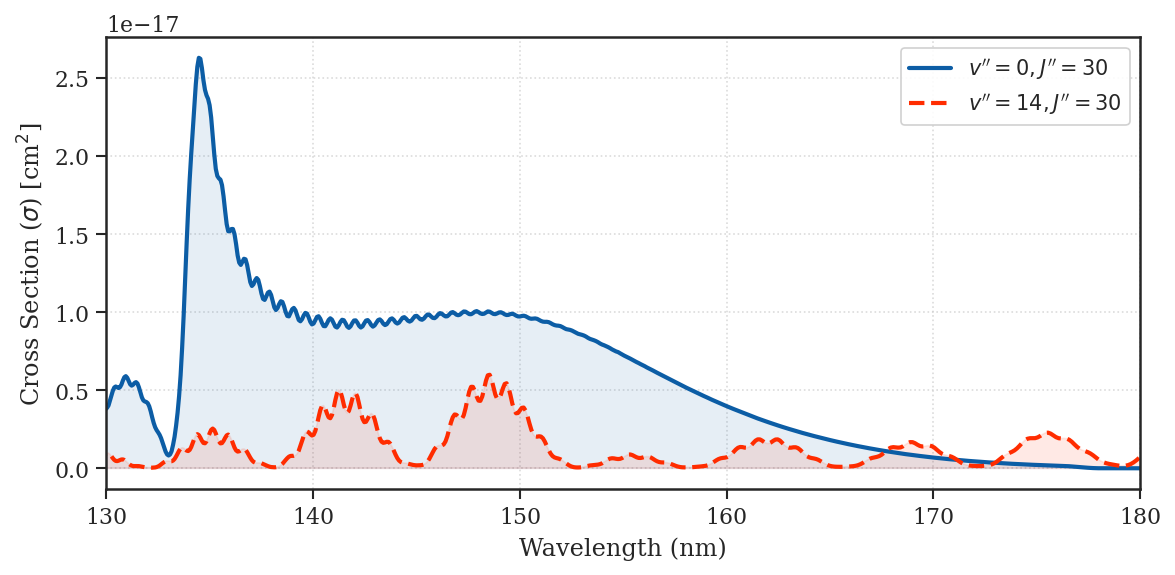

In [279]:
# LATER, IN YOUR PLOTTING SCRIPT:
# 3. Read from Parquet
file_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/cross_sections.parquet'
df_loaded = pd.read_parquet(file_path, engine='pyarrow')

# 4. Convert the lists back to fast NumPy arrays
df_loaded['cross_section'] = df_loaded['cross_section'].apply(np.array)
import matplotlib.pyplot as plt

# --- Dissertation-Grade Plot Styling ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 12, 
    "figure.dpi": 150, 
    "grid.alpha": 0.3, 
    "legend.frameon": True, 
    "legend.fontsize": 10,
    "axes.linewidth": 1.2
})

# Nature-style distinct color palette
COLORS = {
    "blue": "#0C5DA5",   
    "red": "#FF2C00",    
    "green": "#00B945",  
    "orange": "#FF9500"  
}

# --- 1. Define the States to Compare ---
# Define the unique combo of quantum numbers for State A and State B
state_A_mask = (df_loaded['down_v'] == 0) & (df_loaded['down_J'] == 30.0) & (df_loaded['down_lambda'] == 0.0)
state_B_mask = (df_loaded['down_v'] == 14) & (df_loaded['down_J'] == 30.0) & (df_loaded['down_lambda'] == 0.0)

# Extract the cross-section arrays
# (Assuming there is exactly one match per mask. .iloc[0] grabs the first matched array)
cs_A = df_loaded[state_A_mask]['cross_section'].iloc[0]
cs_B = df_loaded[state_B_mask]['cross_section'].iloc[0]



# --- 2. Visualization ---
fig, ax = plt.subplots(figsize=(8, 4))

# Plot State A
ax.plot(1e7/nu_range, cs_A, color=COLORS["blue"], lw=2.0, 
        label=r"$v''=0, J''=30$")
ax.fill_between(1e7/nu_range, cs_A, color=COLORS["blue"], alpha=0.1)

# Plot State B
ax.plot(1e7/nu_range, cs_B, color=COLORS["red"], lw=2.0, linestyle='--', 
        label=r"$v''=14, J''=30$")
ax.fill_between(1e7/nu_range, cs_B, color=COLORS["red"], alpha=0.1)

# --- 3. Formatting ---
# ax.set_title('Cross-Section Comparison of Selected Quantum States', pad=15)
ax.set_xlabel('Wavelength (nm)') # Update with your real units
ax.set_ylabel(r'Cross Section ($\sigma$) [cm$^2$]')   # Update with your real units

# Make it look clean and professional
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_xlim(130,180)

# Minimalist top/right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('cross_section_comparison.pdf', format='pdf', bbox_inches='tight', dpi = 400)
plt.show()

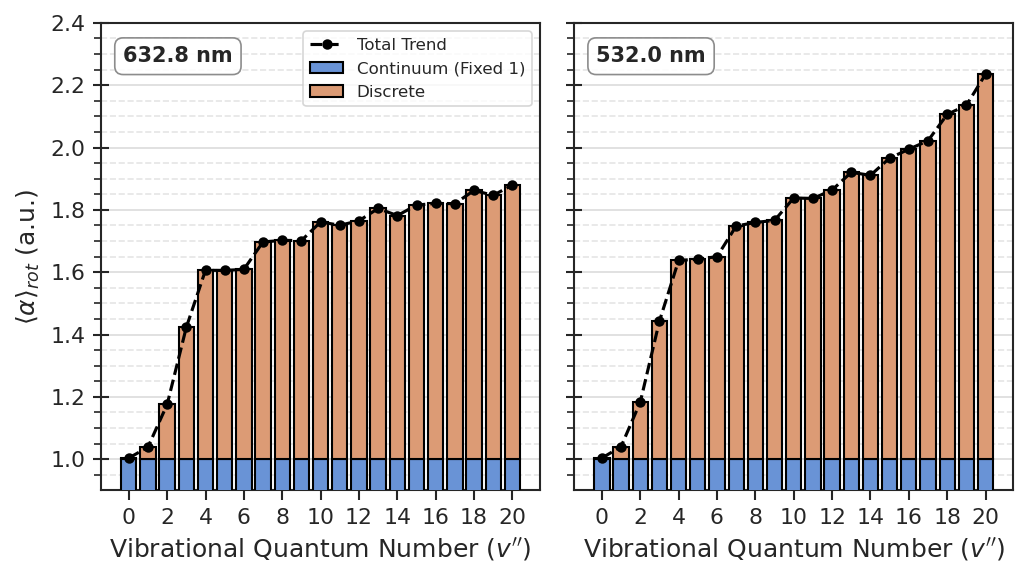

In [288]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Constants and Parameters
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125
T_ROT = 300  # Fixed rotational temperature

# New Theoretical Assumption
CONSTANT_CONT_OFFSET = 1

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# Fixed quantum numbers
FIXED_OMEGA = 0
FIXED_LAMBDA = 0
FIXED_SIGMA = 0

# ==========================================
# 2. Database IO (DuckDB)
# ==========================================
# We still pull down_energy from the continuum table to calculate the Boltzmann weights properly,
# but we only need to extract the discrete polarizabilities now.
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    COALESCE(d."pol_532.0nm", 0) AS disc_532_0nm,
    COALESCE(d."pol_632.8nm", 0) AS disc_632_8nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v 
    AND c.down_J = d.down_J
    AND c.down_omega = d.down_omega
    AND c.down_lambda = d.down_lambda
    AND c.down_sigma = d.down_sigma
WHERE 
    c.down_v <= {MAX_V}
    AND c.down_J <= {MAX_J}
    AND c.down_omega = {FIXED_OMEGA}
    AND c.down_lambda = {FIXED_LAMBDA}
    AND c.down_sigma = {FIXED_SIGMA}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# Normalize energy
df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY

# ==========================================
# 3. Rotational Boltzmann Averaging per v-level
# ==========================================
exponent = (-h * c * df['delta_E']) / (k_B * T_ROT)
df['weight'] = (2 * df['down_J'] + 1) * np.exp(exponent)

wavelengths = ['532_0nm', '632_8nm']

# Only multiply discrete polarizabilities by weight
for wl in wavelengths:
    df[f'w_disc_{wl}'] = df['weight'] * df[f'disc_{wl}']

agg_dict = {'weight': 'sum'}
for wl in wavelengths:
    agg_dict[f'w_disc_{wl}'] = 'sum'

grouped = df.groupby('down_v').agg(agg_dict).reset_index()

# Calculate final averages and inject the constant continuum offset
for wl in wavelengths:
    grouped[f'avg_disc_{wl}'] = np.where(grouped['weight'] > 0, grouped[f'w_disc_{wl}'] / grouped['weight'], 0.0)
    grouped[f'avg_cont_{wl}'] = CONSTANT_CONT_OFFSET  # <--- Forces the 1.5 base

# ==========================================
# 4. Plotting: Stacked Bar Charts
# ==========================================
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

plot_config = [
    ('532_0nm', '532.0 nm'),
    ('632_8nm', '632.8 nm')
]
plot_config = plot_config[::-1]

cont_color = "#6993D6"  
disc_color = "#DC9B75"  

for i, (col_key, label) in enumerate(plot_config):
    ax = axes[i]
    v_levels = grouped['down_v']
    cont_vals = grouped[f'avg_cont_{col_key}']
    disc_vals = grouped[f'avg_disc_{col_key}']
    
    # Plot Continuum (Flat Base)
    ax.bar(v_levels, cont_vals, label=f'Continuum (Fixed {CONSTANT_CONT_OFFSET})', color=cont_color, edgecolor='black', linewidth=1, zorder=3)
    # Plot Discrete (Stacked)
    ax.bar(v_levels, disc_vals, bottom=cont_vals, label='Discrete', color=disc_color, edgecolor='black', linewidth=1, zorder=3)
     # Plot Trendline (connecting the totals)
    ax.plot(v_levels, (disc_vals + cont_vals), color='black', linestyle='--', marker='o', markersize=4, 
            linewidth=1.5, label='Total Trend', zorder=5)
    # --- Formatting ---
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=10, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9), zorder=4)

    ax.set_xlabel("Vibrational Quantum Number ($v''$)", fontsize=12)
    ax.set_xticks(range(0, MAX_V + 1, 2))
    
    # Bumped y-limit slightly to accommodate the 1.2 offset + discrete values
    ax.set_ylim(1, 2) 
    
    
    # Tick Control
    ax.minorticks_on()
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    # Make major Y ticks cross ('inout')
    ax.tick_params(axis='y', which='major', direction='inout', length=8, width=1)
    ax.set_ylim(0.9,2.4)
    # Grid Control
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.7, zorder=0) 
    ax.grid(True, which='minor', axis='y', linestyle='--', alpha=0.5, zorder=0) 
    ax.grid(False, axis='x') 
    
    if i == 0:
        ax.set_ylabel(r"$\langle\alpha\rangle_{rot}$ (a.u.)", fontsize=12)
        ax.legend(frameon=True, loc='upper right', fontsize=8)
plt.savefig('pol_constantoffset.pdf', dpi=400)
plt.tight_layout()
plt.show()

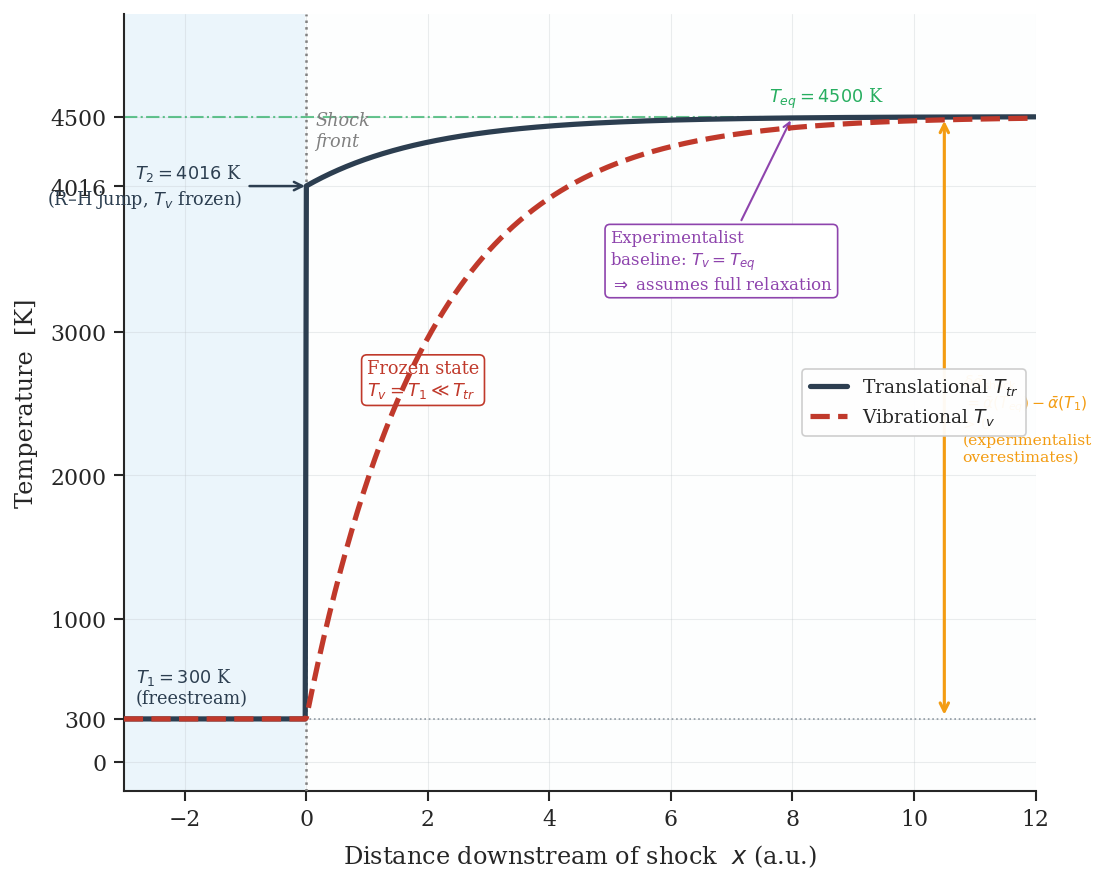

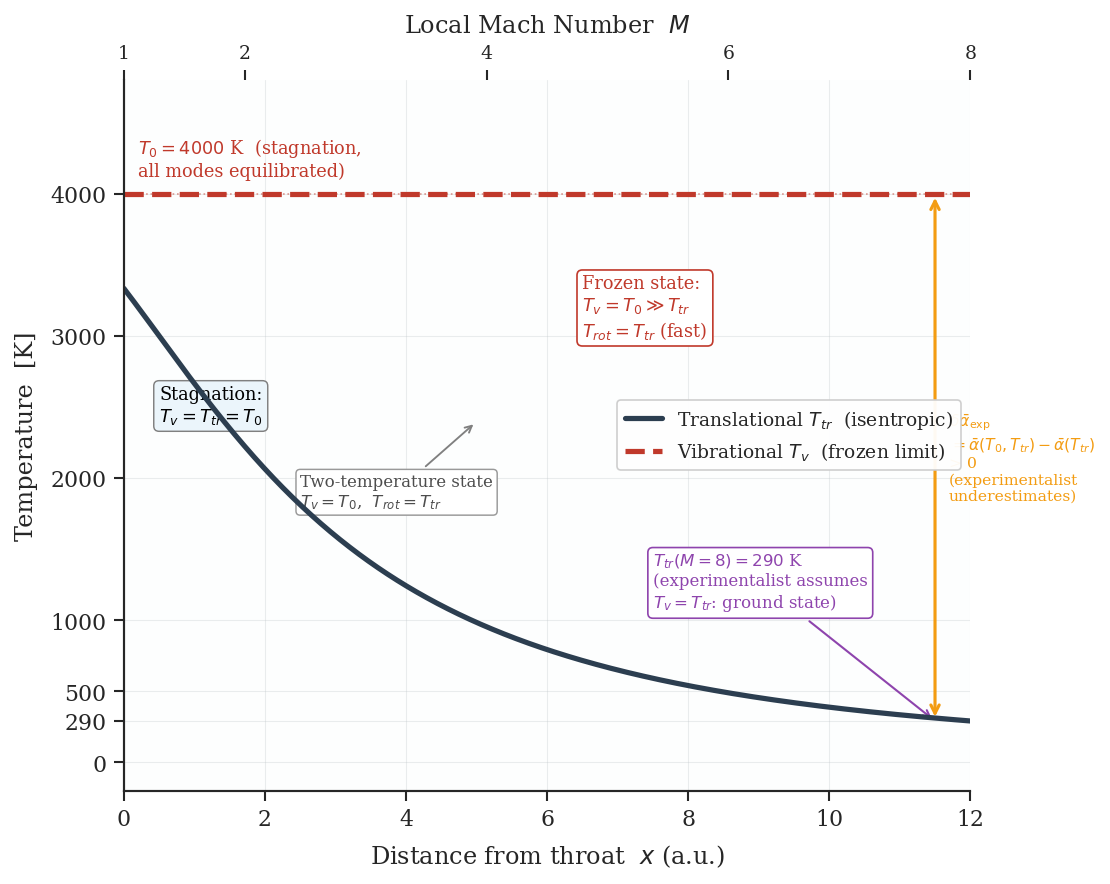

In [293]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.8",
    "legend.fontsize": 9,
})

GAMMA = 1.4

# ── Shock values ──────────────────────────────────────────────────────────────
T1_s  = 300.0
M_s   = 8.0
T2_s  = T1_s * (2*GAMMA*M_s**2-(GAMMA-1)) * ((GAMMA-1)*M_s**2+2) / ((GAMMA+1)**2*M_s**2)
Teq_s = 4500.0
tau_x = 2.0

x_shock   = np.linspace(-3, 12, 800)
T_tr_shock = np.ones_like(x_shock) * T1_s
T_v_shock  = np.ones_like(x_shock) * T1_s
post       = x_shock >= 0
T_tr_shock[post] = Teq_s + (T2_s - Teq_s) * np.exp(-x_shock[post] / tau_x)
T_v_shock[post]  = Teq_s - (Teq_s - T1_s) * np.exp(-x_shock[post] / tau_x)

# ── Nozzle values ─────────────────────────────────────────────────────────────
T0_n   = 4000.0
M_exit = 8.0
x_nozzle = np.linspace(0, 12, 800)
M_nozzle = 1.0 + (M_exit - 1.0) * (x_nozzle / np.max(x_nozzle))
T_tr_nozzle = T0_n / (1 + ((GAMMA-1)/2) * M_nozzle**2)
T_v_nozzle  = np.ones_like(x_nozzle) * T0_n
T_tr_exit   = T_tr_nozzle[-1]

# ── Colour palette ────────────────────────────────────────────────────────────
C_TR   = "#2C3E50"   # dark slate  — translational
C_TV   = "#C0392B"   # deep red    — vibrational
C_EQ   = "#27AE60"   # green       — equilibrium
C_BASE = "#8E44AD"   # purple      — experimentalist baseline
C_SPAN = "#F39C12"   # amber       — error span
C_GRID = "#BDC3C7"

# ═══════════════════════════════════════════════════════════════════
#  FIGURE 1 — NORMAL SHOCK
# ═══════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(7.5, 6))
fig1.patch.set_facecolor("white")
ax = ax1

# shaded regions
ax.axvspan(-3, 0, color="#EBF5FB", zorder=0, label="__nolabel__")
ax.axvspan(0, 12,  color="#FDFEFE", zorder=0)

# shock front
ax.axvline(0, color="gray", lw=1.2, ls=":", zorder=3)
ax.text(0.15, T2_s + 250, "Shock\nfront", fontsize=8.5, color="gray",
        va="bottom", style="italic")

# temperature curves
ax.plot(x_shock, T_tr_shock, color=C_TR, lw=2.5, zorder=4,
        label=r"Translational $T_{tr}$")
ax.plot(x_shock, T_v_shock,  color=C_TV, lw=2.5, ls="--", zorder=4,
        label=r"Vibrational $T_v$")

# ── key horizontal reference lines ──
# T1
ax.axhline(T1_s, color=C_TR, lw=0.8, ls=":", alpha=0.5)
ax.text(-2.8, T1_s + 80, f"$T_1 = {T1_s:.0f}$ K\n(freestream)", fontsize=8.5,
        color=C_TR, va="bottom")

# T2
ax.annotate("", xy=(0.05, T2_s), xytext=(-1.0, T2_s),
            arrowprops=dict(arrowstyle="->", color=C_TR, lw=1.2))
ax.text(-1.05, T2_s, f"$T_2 = {T2_s:.0f}$ K\n(R–H jump, $T_v$ frozen)", fontsize=8.5,
        color=C_TR, ha="right", va="center")

# Teq
ax.axhline(Teq_s, color=C_EQ, lw=1.0, ls="-.", alpha=0.7)
ax.text(9.5, Teq_s + 100, f"$T_{{eq}} = {Teq_s:.0f}$ K", fontsize=8.5,
        color=C_EQ, ha="right")

# ── error span: T1 vs Teq ──
ax.annotate("", xy=(10.5, Teq_s), xytext=(10.5, T1_s),
            arrowprops=dict(arrowstyle="<->", color=C_SPAN, lw=1.5))
ax.text(10.8, (Teq_s + T1_s)/2,
        r"$\delta\bar{\alpha}_{\rm shock}$" + "\n" +
        r"$= \bar{\alpha}(T_{eq}) - \bar{\alpha}(T_1)$" + "\n> 0\n(experimentalist\noverestimates)",
        fontsize=7.5, color=C_SPAN, va="center")

# ── baseline box ──
ax.annotate("Experimentalist\nbaseline: $T_v = T_{eq}$\n" +
            r"$\Rightarrow$ assumes full relaxation",
            xy=(8, Teq_s), xytext=(5, Teq_s - 1200),
            fontsize=8, color=C_BASE,
            arrowprops=dict(arrowstyle="->", color=C_BASE, lw=1.0),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_BASE, lw=0.8))

# ── frozen state label ──
ax.text(1.0, (T2_s + T1_s)/2 + 400,
        "Frozen state\n" + r"$T_v = T_1 \ll T_{tr}$",
        fontsize=8.5, color=C_TV,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_TV, lw=0.8))

ax.set_xlim(-3, 12)
ax.set_ylim(-200, T2_s + 1200)
ax.set_xlabel("Distance downstream of shock  $x$ (a.u.)", labelpad=6)
ax.set_ylabel("Temperature  [K]", labelpad=6)
# ax.set_title("(a)  Normal Shock  —  Sudden Heating\n"
#              r"$M_1 = 8,\\ T_1 = 300$ K", fontsize=11, pad=10)
ax.legend(loc="center right", frameon=True)
ax.set_yticks([0, T1_s, 1000, 2000, 3000, T2_s, Teq_s])
ax.set_yticklabels(["0", f"{T1_s:.0f}", "1000", "2000", "3000",
                    f"{T2_s:.0f}", f"{Teq_s:.0f}"])
ax.grid(True, color=C_GRID, lw=0.5)

plt.tight_layout()
plt.savefig('nonequil_schematic_a.svg', format='svg', bbox_inches='tight', dpi=400)
plt.show()

# ═══════════════════════════════════════════════════════════════════
#  FIGURE 2 — NOZZLE EXPANSION
# ═══════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(7.5, 6))
fig2.patch.set_facecolor("white")
ax = ax2

# Mach axis on top
ax_top = ax.twiny()
ax_top.set_xlim(1, M_exit)
ax_top.set_xlabel("Local Mach Number  $M$", labelpad=6)
ax_top.set_xticks([1, 2, 4, 6, 8])
ax_top.tick_params(labelsize=9)

# background
ax.set_facecolor("#FDFEFE")

# curves
ax.plot(x_nozzle, T_tr_nozzle, color=C_TR, lw=2.5, zorder=4,
        label=r"Translational $T_{tr}$  (isentropic)")
ax.plot(x_nozzle, T_v_nozzle,  color=C_TV, lw=2.5, ls="--", zorder=4,
        label=r"Vibrational $T_v$  (frozen limit)")

# ── T0 reference ──
ax.axhline(T0_n, color=C_TV, lw=0.8, ls=":", alpha=0.5)
ax.text(0.2, T0_n + 120, f"$T_0 = {T0_n:.0f}$ K  (stagnation,\nall modes equilibrated)",
        fontsize=8.5, color=C_TV)

# ── T_tr at exit ──
ax.annotate("", xy=(11.5, T_tr_exit), xytext=(11.5, T0_n),
            arrowprops=dict(arrowstyle="<->", color=C_SPAN, lw=1.5))
ax.text(11.7, (T0_n + T_tr_exit)/2,
        r"$\delta\bar{\alpha}_{\rm exp}$" + "\n" +
        r"$= \bar{\alpha}(T_0,T_{tr}) - \bar{\alpha}(T_{tr})$" + "\n> 0\n(experimentalist\nunderestimates)",
        fontsize=7.5, color=C_SPAN, va="center")

ax.annotate(f"$T_{{tr}}(M=8) = {T_tr_exit:.0f}$ K\n(experimentalist assumes\n" +
            r"$T_v = T_{tr}$: ground state)",
            xy=(11.5, T_tr_exit), xytext=(7.5, T_tr_exit + 800),
            fontsize=8, color=C_BASE,
            arrowprops=dict(arrowstyle="->", color=C_BASE, lw=1.0),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_BASE, lw=0.8))

# ── stagnation label ──
ax.text(0.5, T0_n * 0.6,
        "Stagnation:\n" + r"$T_v = T_{tr} = T_0$",
        fontsize=8.5, color="black",
        bbox=dict(boxstyle="round,pad=0.3", fc="#EBF5FB", ec="gray", lw=0.7))

# ── frozen state label ──
ax.text(6.5, T0_n * 0.75,
        "Frozen state:\n" + r"$T_v = T_0 \gg T_{tr}$" + "\n" +
        r"$T_{rot} = T_{tr}$ (fast)",
        fontsize=8.5, color=C_TV,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_TV, lw=0.8))

# ── two-temperature annotation ──
ax.annotate("Two-temperature state\n" +
            r"$T_v = T_0$,  $T_{rot} = T_{tr}$",
            xy=(5, (T0_n + T_tr_nozzle[400])/2),
            xytext=(2.5, 1800),
            fontsize=8, color="0.3",
            arrowprops=dict(arrowstyle="->", color="0.5", lw=0.9),
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", lw=0.7))

ax.set_xlim(0, 12)
ax.set_ylim(-200, T0_n + 800)
ax.set_xlabel("Distance from throat  $x$ (a.u.)", labelpad=6)
ax.set_ylabel("Temperature  [K]", labelpad=6)
# ax.set_title("(b)  Nozzle Expansion  —  Rapid Cooling\n"
            #  r"$T_0 = 4000$ K,  exit $M = 8$", fontsize=11, pad=28)
ax.legend(loc="center right", frameon=True)
ax.set_yticks([0, 500, T_tr_exit, 1000, 2000, 3000, T0_n])
ax.set_yticklabels(["0", "500", f"{T_tr_exit:.0f}", "1000",
                    "2000", "3000", f"{T0_n:.0f}"])
ax.grid(True, color=C_GRID, lw=0.5)

plt.tight_layout()
plt.savefig('nonequil_schematic_b.svg', format='svg', bbox_inches='tight', dpi=400)
plt.show()


T1 (K) | Mach | T2 (Froz) |   Teq (K) |  WL (nm) | a_froz (a.u.) |   a_eq (a.u.) |  % Error
----------------------------------------------------------------------------------------------------
   300 |  2.0 |     506.2 |     499.3 | 632.8 nm |       1.59127 |       1.59467 |   0.213%
   300 |  2.0 |     506.2 |     499.3 | 400.0 nm |       1.73552 |       1.73975 |   0.243%
   300 |  6.0 |    2382.2 |    2052.8 | 632.8 nm |       1.59127 |       1.64328 |   3.268%
   300 |  6.0 |    2382.2 |    2052.8 | 400.0 nm |       1.73552 |       1.80795 |   4.173%
   300 | 10.0 |    6116.2 |    4951.6 | 632.8 nm |       1.59127 |       1.63591 |   2.805%
   300 | 10.0 |    6116.2 |    4951.6 | 400.0 nm |       1.73552 |       1.84310 |   6.198%
----------------------------------------------------------------------------------------------------
   700 |  2.0 |    1181.2 |    1109.6 | 632.8 nm |       1.59964 |       1.61301 |   0.836%
   700 |  2.0 |    1181.2 |    1109.6 | 400.0 nm |       1.746

/tmp/ipykernel_1667820/2599944906.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


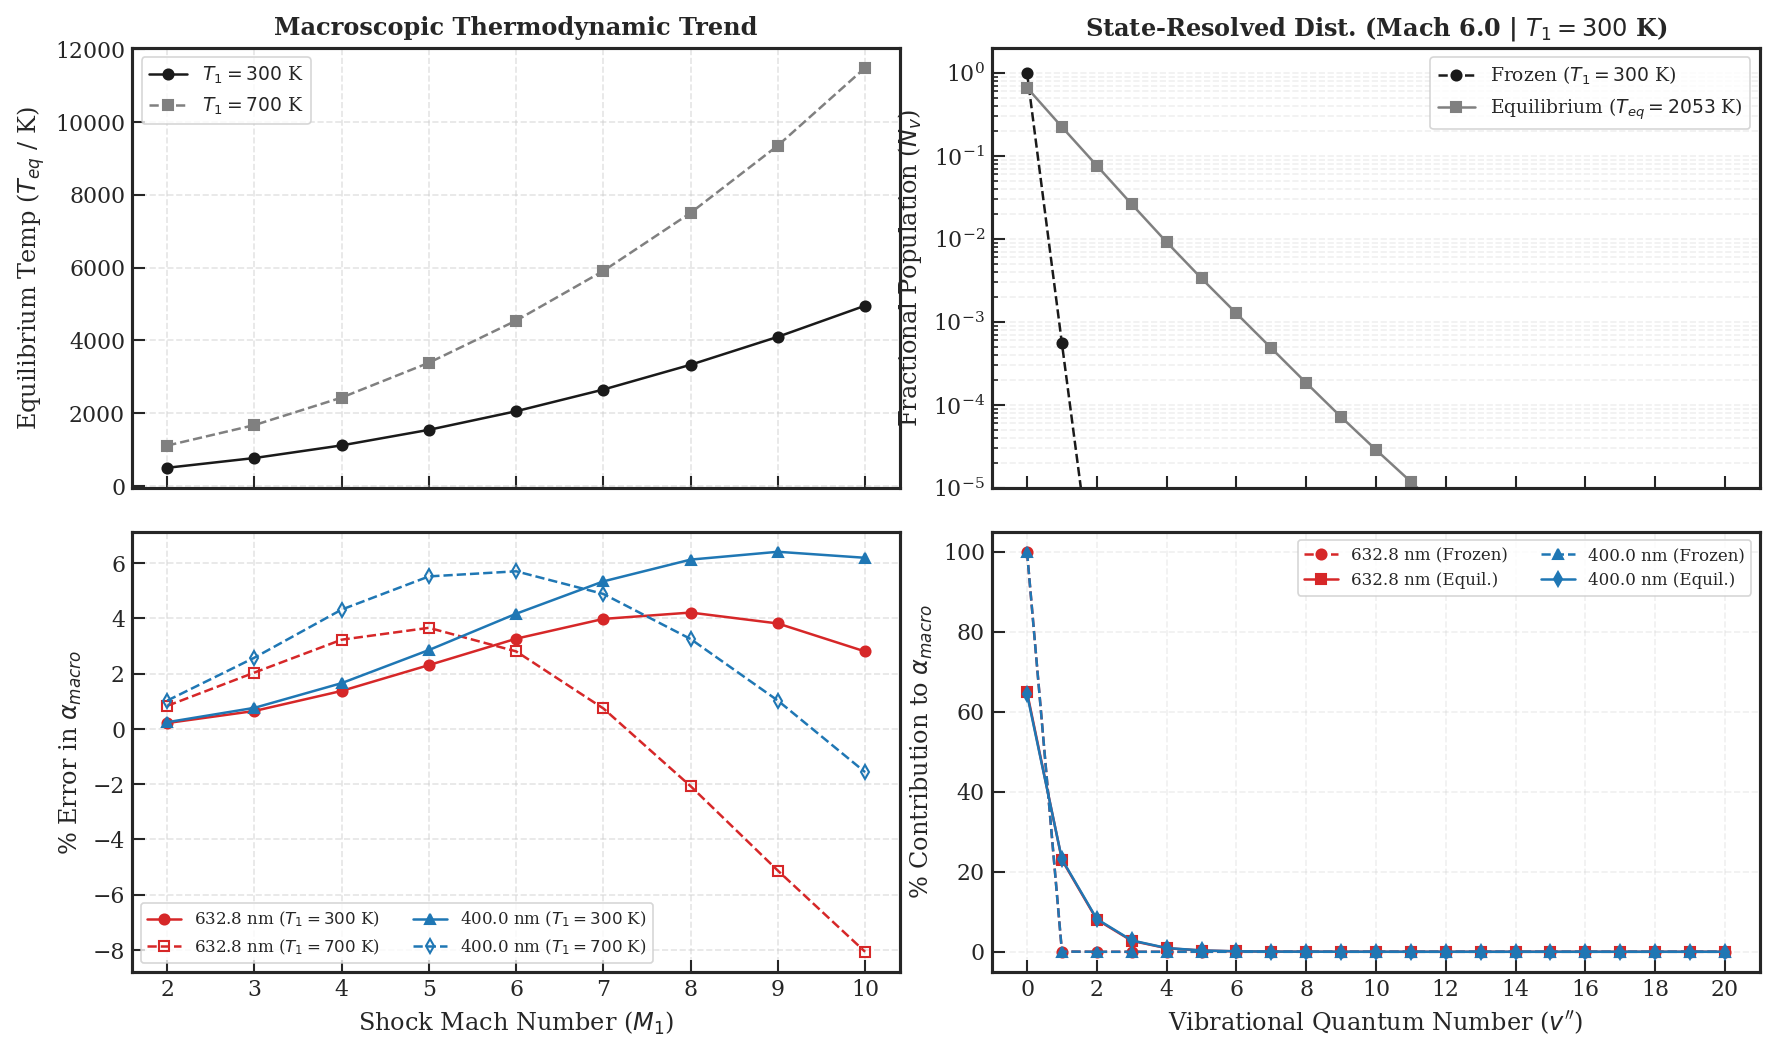

In [73]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.ticker import AutoMinorLocator

# --- Dissertation-Grade Plot Styling ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 11, 
    "figure.dpi": 150, 
    "grid.alpha": 0.3,
    "legend.frameon": True,
    "legend.fontsize": 9
})

# ==========================================
# 1. Constants & Configuration
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# --- UPDATED: Swapped 532.0nm for 400.0nm ---
WAVELENGTHS = {
    'pol_632_8nm': '"pol_632.8nm"',
    'pol_400_0nm': '"pol_400.0nm"'
}
WAVELENGTH_LABELS = {
    'pol_632_8nm': '632.8 nm',
    'pol_400_0nm': '400.0 nm'
}

# --- O2 Constants (Pure Diatomic) ---
R_UNIV  = 8.31446          
MW_O2   = 0.031998         
Rs      = R_UNIV / MW_O2   
kB_hc   = 0.69503          

# --- DUO DATABASE INPUTS (cm^-1) for Shock Solver ---
duo_levels_cm1 = np.array([
    0.0, 1556.5833, 3086.2416, 4596.8598, 6084.1886, 7548.2948, 8989.6449, 
    10408.4501, 11804.7729, 13178.2704, 14528.5013, 15855.2428, 17158.5527, 18438.5624, 19695.1485, 20928.2146, 22137.6018, 23323.0549, 24484.2576, 25620.7956, 26732.2882
])
duo_levels_K = duo_levels_cm1 / kB_hc 

# ==========================================
# 2. Database Load
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    (COALESCE(c.{WAVELENGTHS['pol_632_8nm']}, 0) + COALESCE(d.{WAVELENGTHS['pol_632_8nm']}, 0)) AS pol_632_8nm,
    (COALESCE(c.{WAVELENGTHS['pol_400_0nm']}, 0) + COALESCE(d.{WAVELENGTHS['pol_400_0nm']}, 0)) AS pol_400_0nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v AND c.down_J = d.down_J
    AND c.down_omega = 0 AND c.down_lambda = 0 AND c.down_sigma = 0
WHERE 
    c.down_v <= {MAX_V} AND c.down_J <= {MAX_J}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY

# ==========================================
# 3. Physics Routines
# ==========================================
def get_h_tr_rot(T):
    return 3.5 * Rs * T

def get_h_vib_sos(T):
    if T < 1.0: return 0.0
    exp_terms = np.exp(-duo_levels_K / T)
    Q = np.sum(exp_terms)
    e_vib_K = np.sum(duo_levels_K * exp_terms) / Q
    return e_vib_K * Rs

def solve_shock_states(M1, T1):
    g = 1.4
    T2 = T1 * (2*g*M1**2 - (g-1)) * ((g-1)*M1**2 + 2) / ((g+1)**2 * M1**2)
    h_target = get_h_tr_rot(T2) + get_h_vib_sos(T1)
    obj_fun = lambda T: get_h_tr_rot(T) + get_h_vib_sos(T) - h_target
    T_eq = brentq(obj_fun, T1, T2)
    return T2, T_eq

def get_alpha_data(T_global, wl_col):
    exponent = (-h * c * df['delta_E']) / (k_B * T_global)
    weight = (2 * df['down_J'] + 1) * np.exp(exponent)
    w_alpha = weight * df[wl_col]
    
    sum_W_total = weight.sum()
    alpha_macro = w_alpha.sum() / sum_W_total
    
    df_temp = pd.DataFrame({'down_v': df['down_v'], 'weight': weight, 'w_alpha': w_alpha})
    grouped = df_temp.groupby('down_v').sum().reset_index()
    
    grouped['N_v'] = grouped['weight'] / sum_W_total
    grouped['alpha_contrib'] = grouped['w_alpha'] / sum_W_total
    
    return alpha_macro, grouped

# ==========================================
# 4. Mach Sweep Execution & Sanity Check Output
# ==========================================
T1_conditions = [300.0, 700.0]
mach_sweep = np.arange(2, 11, 1)

thermo_results = {T1: {'M': [], 'Teq': []} for T1 in T1_conditions}
alpha_results = {wl: {T1: {'err': []} for T1 in T1_conditions} for wl in WAVELENGTHS.keys()}

mach6_thermo = {} 
mach6_alpha = {wl: {} for wl in WAVELENGTHS.keys()}

print(f"{'T1 (K)':>6} | {'Mach':>4} | {'T2 (Froz)':>9} | {'Teq (K)':>9} | {'WL (nm)':>8} | {'a_froz (a.u.)':>13} | {'a_eq (a.u.)':>13} | {'% Error':>8}")
print("-" * 100)

for T1 in T1_conditions:
    for M in mach_sweep:
        T2, Teq = solve_shock_states(M, T1)
        
        thermo_results[T1]['M'].append(M)
        thermo_results[T1]['Teq'].append(Teq)
        
        for wl_col in WAVELENGTHS.keys():
            wl_label = WAVELENGTH_LABELS[wl_col]
            alpha_froz, grouped_froz = get_alpha_data(T1, wl_col)
            alpha_eq, grouped_eq = get_alpha_data(Teq, wl_col)
            
            err_pct = ((alpha_eq - alpha_froz) / alpha_froz) * 100.0
            alpha_results[wl_col][T1]['err'].append(err_pct)
            
            if M in [2, 6, 10]:
                print(f"{T1:6.0f} | {M:4.1f} | {T2:9.1f} | {Teq:9.1f} | {wl_label:>8} | {alpha_froz:13.5f} | {alpha_eq:13.5f} | {err_pct:7.3f}%")
            
            if M == 6 and T1 == 300.0:
                mach6_thermo['v'] = grouped_froz['down_v']
                mach6_thermo['N_v_froz'] = grouped_froz['N_v']
                mach6_thermo['N_v_eq'] = grouped_eq['N_v']
                mach6_thermo['Teq'] = Teq
                
                mach6_alpha[wl_col]['a_con_froz'] = (grouped_froz['alpha_contrib'] / alpha_froz) * 100.0
                mach6_alpha[wl_col]['a_con_eq'] = (grouped_eq['alpha_contrib'] / alpha_eq) * 100.0
                
    print("-" * 100) 

# ==========================================
# 5. Visualization (Unified 2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8), gridspec_kw={'hspace': 0.1, 'wspace': 0.12})

axes[0, 0].sharex(axes[1, 0])
axes[0, 1].sharex(axes[1, 1])

# Colors: Red for 632.8, Blue for 400.0
c_632 = '#d62728' 
c_400 = '#1f77b4' 

# ---------------------------------------------------------
# Top Left: Equilibrium Temperature vs Mach 
# ---------------------------------------------------------
ax_teq = axes[0, 0]
ax_teq.plot(thermo_results[300]['M'], thermo_results[300]['Teq'], color='k', linestyle='-', marker='o', label=r'$T_1=300$ K')
ax_teq.plot(thermo_results[700]['M'], thermo_results[700]['Teq'], color='gray', linestyle='--', marker='s', label=r'$T_1=700$ K')
ax_teq.set_ylabel('Equilibrium Temp ($T_{eq}$ / K)')
ax_teq.set_title('Macroscopic Thermodynamic Trend', fontweight='bold')
ax_teq.grid(True, linestyle='--', alpha=0.5)
ax_teq.legend(loc='upper left')
plt.setp(ax_teq.get_xticklabels(), visible=False)

# ---------------------------------------------------------
# Bottom Left: % Error vs Mach 
# ---------------------------------------------------------
ax_err = axes[1, 0]
# 632.8 nm
ax_err.plot(thermo_results[300]['M'], alpha_results['pol_632_8nm'][300]['err'], color=c_632, linestyle='-', marker='o', label=r'632.8 nm ($T_1=300$ K)')
ax_err.plot(thermo_results[700]['M'], alpha_results['pol_632_8nm'][700]['err'], color=c_632, linestyle='--', marker='s', fillstyle='none', label=r'632.8 nm ($T_1=700$ K)')
# 400.0 nm
ax_err.plot(thermo_results[300]['M'], alpha_results['pol_400_0nm'][300]['err'], color=c_400, linestyle='-', marker='^', label=r'400.0 nm ($T_1=300$ K)')
ax_err.plot(thermo_results[700]['M'], alpha_results['pol_400_0nm'][700]['err'], color=c_400, linestyle='--', marker='d', fillstyle='none', label=r'400.0 nm ($T_1=700$ K)')

ax_err.set_ylabel(r'% Error in $\alpha_{macro}$')
ax_err.set_xlabel('Shock Mach Number ($M_1$)')
ax_err.grid(True, linestyle='--', alpha=0.5)
ax_err.legend(loc='lower left', ncol=2, fontsize=8) # Moved to upper left for visibility

# ---------------------------------------------------------
# Top Right: Fractional Population 
# ---------------------------------------------------------
ax_pop = axes[0, 1]
v_levels = mach6_thermo['v']
ax_pop.plot(v_levels, mach6_thermo['N_v_froz'], color='k', linestyle='--', marker='o', label=r'Frozen ($T_1=300$ K)')
ax_pop.plot(v_levels, mach6_thermo['N_v_eq'], color='gray', linestyle='-', marker='s', label=f"Equilibrium ($T_{{eq}}={mach6_thermo['Teq']:.0f}$ K)")
ax_pop.set_yscale('log')
ax_pop.set_ylim(1e-5, 2)
ax_pop.set_ylabel('Fractional Population ($N_v$)')
ax_pop.set_title(f'State-Resolved Dist. (Mach 6.0 | $T_1=300$ K)', fontweight='bold')
ax_pop.grid(True, which='both', axis='y', linestyle='--', alpha=0.3)
ax_pop.legend(loc='upper right')
plt.setp(ax_pop.get_xticklabels(), visible=False)

# ---------------------------------------------------------
# Bottom Right: % Alpha Contributions
# ---------------------------------------------------------
ax_alp = axes[1, 1]
# 632.8 nm
ax_alp.plot(v_levels, mach6_alpha['pol_632_8nm']['a_con_froz'], color=c_632, linestyle='--', marker='o', label=r'632.8 nm (Frozen)')
ax_alp.plot(v_levels, mach6_alpha['pol_632_8nm']['a_con_eq'], color=c_632, linestyle='-', marker='s', label=r'632.8 nm (Equil.)')
# 400.0 nm
ax_alp.plot(v_levels, mach6_alpha['pol_400_0nm']['a_con_froz'], color=c_400, linestyle='--', marker='^', label=r'400.0 nm (Frozen)')
ax_alp.plot(v_levels, mach6_alpha['pol_400_0nm']['a_con_eq'], color=c_400, linestyle='-', marker='d', label=r'400.0 nm (Equil.)')

ax_alp.set_ylabel(r'% Contribution to $\alpha_{macro}$')
ax_alp.set_xlabel("Vibrational Quantum Number ($v''$)")
ax_alp.set_xticks(range(0, MAX_V + 1, 2))
ax_alp.grid(True, linestyle='--', alpha=0.3)
ax_alp.legend(loc='upper right', ncol=2, fontsize=8)

plt.savefig('fig_shock_results_400nm.pdf', format='pdf', dpi=400, bbox_inches='tight')

plt.tight_layout()
plt.show()

T0 (K) | Mach |  T_tr (K) |  WL (nm) | a_true (a.u.) | a_assum (a.u.) |  % Error
------------------------------------------------------------------------------------------
  2000 |  1.0 |    1666.7 | 632.8 nm |       1.63809 |        1.63214 |  -0.363%
  2000 |  1.0 |    1666.7 | 400.0 nm |       1.80111 |        1.79103 |  -0.560%
  2000 |  8.0 |     144.9 | 632.8 nm |       1.61146 |        1.58922 |  -1.380%
  2000 |  8.0 |     144.9 | 400.0 nm |       1.76919 |        1.73307 |  -2.041%
  2000 | 10.0 |      95.2 | 632.8 nm |       1.61036 |        1.58858 |  -1.352%
  2000 | 10.0 |      95.2 | 400.0 nm |       1.76789 |        1.73231 |  -2.013%
------------------------------------------------------------------------------------------
  4000 |  1.0 |    3333.3 | 632.8 nm |       1.65276 |        1.65833 |   0.337%
  4000 |  1.0 |    3333.3 | 400.0 nm |       1.84574 |        1.84202 |  -0.202%
  4000 |  8.0 |     289.9 | 632.8 nm |       1.61680 |        1.59113 |  -1.588%
  4000 |

/tmp/ipykernel_1667820/2544094623.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


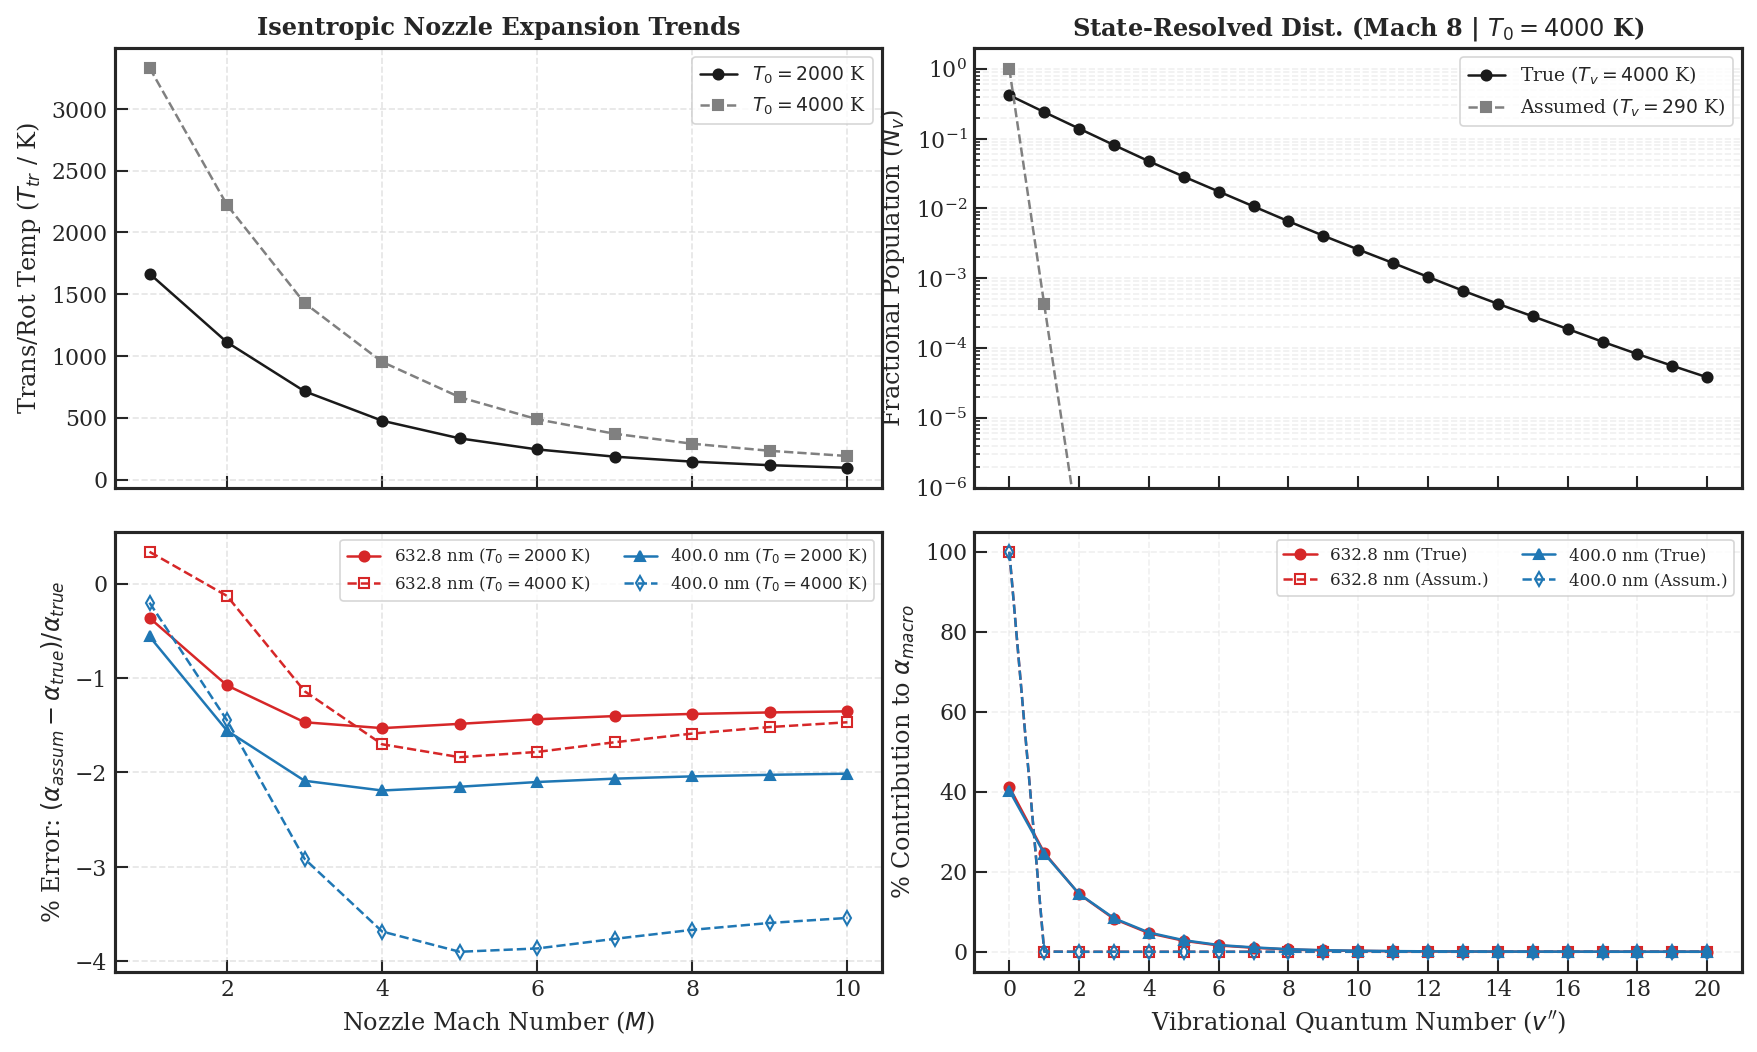

In [71]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Dissertation-Grade Plot Styling ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 11, 
    "figure.dpi": 150, 
    "grid.alpha": 0.3,
    "legend.frameon": True,
    "legend.fontsize": 9
})

# ==========================================
# 1. Constants & Configuration
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K
GAMMA = 1.4

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# --- UPDATED: Swapped 532.0nm for 400.0nm ---
WAVELENGTHS = {
    'pol_632_8nm': '"pol_632.8nm"',
    'pol_400_0nm': '"pol_400.0nm"'
}
WAVELENGTH_LABELS = {
    'pol_632_8nm': '632.8 nm',
    'pol_400_0nm': '400.0 nm'
}

# ==========================================
# 2. Database Load & Energy Split
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    (COALESCE(c.{WAVELENGTHS['pol_632_8nm']}, 0) + COALESCE(d.{WAVELENGTHS['pol_632_8nm']}, 0)) AS pol_632_8nm,
    (COALESCE(c.{WAVELENGTHS['pol_400_0nm']}, 0) + COALESCE(d.{WAVELENGTHS['pol_400_0nm']}, 0)) AS pol_400_0nm
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v AND c.down_J = d.down_J
    AND c.down_omega = 0 AND c.down_lambda = 0 AND c.down_sigma = 0
WHERE 
    c.down_v <= {MAX_V} AND c.down_J <= {MAX_J}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# Normalize energy and extract distinct Vib and Rot components
df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY
df['E_vib'] = df.groupby('down_v')['delta_E'].transform('min')
df['E_rot'] = df['delta_E'] - df['E_vib']

# ==========================================
# 3. Physics Routines (Expansion)
# ==========================================
def T_tr_isentropic(M, T0):
    """Calculates the cold translational/rotational temp in an isentropic nozzle."""
    return T0 / (1 + ((GAMMA - 1) / 2) * M**2)

def get_alpha_two_temp(T_vib, T_rot, wl_col):
    """
    Computes alpha using independent vibrational and rotational temperatures.
    - True Baseline: T_vib = T0 (frozen), T_rot = T_tr (cooled)
    - Assumed Baseline: T_vib = T_tr (cooled), T_rot = T_tr (cooled)
    """
    exp_vib = (-h * c * df['E_vib']) / (k_B * T_vib)
    exp_rot = (-h * c * df['E_rot']) / (k_B * T_rot)
    
    weight = (2 * df['down_J'] + 1) * np.exp(exp_vib + exp_rot)
    w_alpha = weight * df[wl_col]
    
    sum_W_total = weight.sum()
    alpha_macro = w_alpha.sum() / sum_W_total
    
    df_temp = pd.DataFrame({'down_v': df['down_v'], 'weight': weight, 'w_alpha': w_alpha})
    grouped = df_temp.groupby('down_v').sum().reset_index()
    
    grouped['N_v'] = grouped['weight'] / sum_W_total
    grouped['alpha_contrib'] = grouped['w_alpha'] / sum_W_total
    
    return alpha_macro, grouped

# ==========================================
# 4. Expansion Sweep & Sanity Checks
# ==========================================
T0_conditions = [2000.0, 4000.0]
mach_sweep = np.arange(1, 11, 1)

thermo_results = {T0: {'M': [], 'T_tr': []} for T0 in T0_conditions}
alpha_results = {wl: {T0: {'err': []} for T0 in T0_conditions} for wl in WAVELENGTHS.keys()}

# For Mach 8 snapshots
M_SNAP = 8
T0_SNAP = 4000.0
mach_snap_thermo = {} 
mach_snap_alpha = {wl: {} for wl in WAVELENGTHS.keys()}

print(f"{'T0 (K)':>6} | {'Mach':>4} | {'T_tr (K)':>9} | {'WL (nm)':>8} | {'a_true (a.u.)':>13} | {'a_assum (a.u.)':>14} | {'% Error':>8}")
print("-" * 90)

for T0 in T0_conditions:
    for M in mach_sweep:
        T_tr = T_tr_isentropic(M, T0)
        
        thermo_results[T0]['M'].append(M)
        thermo_results[T0]['T_tr'].append(T_tr)
        
        for wl_col in WAVELENGTHS.keys():
            wl_label = WAVELENGTH_LABELS[wl_col]
            
            # TRUE STATE: Vib frozen at T0, Rot cooled to T_tr
            alpha_true, grouped_true = get_alpha_two_temp(T_vib=T0, T_rot=T_tr, wl_col=wl_col)
            
            # ASSUMED STATE: Fully equilibrated at cold T_tr
            alpha_assum, grouped_assum = get_alpha_two_temp(T_vib=T_tr, T_rot=T_tr, wl_col=wl_col)
            
            # Experimentalist Error (Baseline = True Flow)
            err_pct = ((alpha_assum - alpha_true) / alpha_true) * 100.0
            alpha_results[wl_col][T0]['err'].append(err_pct)
            
            # Print Sanity Checks
            if M in [1, M_SNAP, 10]:
                print(f"{T0:6.0f} | {M:4.1f} | {T_tr:9.1f} | {wl_label:>8} | {alpha_true:13.5f} | {alpha_assum:14.5f} | {err_pct:7.3f}%")
            
            # Save Snapshot
            if M == M_SNAP and T0 == T0_SNAP:
                mach_snap_thermo['v'] = grouped_true['down_v']
                mach_snap_thermo['N_v_true'] = grouped_true['N_v']
                mach_snap_thermo['N_v_assum'] = grouped_assum['N_v']
                mach_snap_thermo['T_tr'] = T_tr
                
                mach_snap_alpha[wl_col]['a_con_true'] = (grouped_true['alpha_contrib'] / alpha_true) * 100.0
                mach_snap_alpha[wl_col]['a_con_assum'] = (grouped_assum['alpha_contrib'] / alpha_assum) * 100.0
                
    print("-" * 90)

# ==========================================
# 5. Visualization (Unified 2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8), gridspec_kw={'hspace': 0.1, 'wspace': 0.12})
axes[0, 0].sharex(axes[1, 0])
axes[0, 1].sharex(axes[1, 1])

# Colors: Red for 632.8, Blue for 400.0
c_632 = '#d62728' 
c_400 = '#1f77b4' 

# ---------------------------------------------------------
# Top Left: Translational Temperature vs Mach
# ---------------------------------------------------------
ax_ttr = axes[0, 0]
ax_ttr.plot(thermo_results[2000]['M'], thermo_results[2000]['T_tr'], color='k', linestyle='-', marker='o', label=r'$T_0=2000$ K')
ax_ttr.plot(thermo_results[4000]['M'], thermo_results[4000]['T_tr'], color='gray', linestyle='--', marker='s', label=r'$T_0=4000$ K')
ax_ttr.set_ylabel('Trans/Rot Temp ($T_{tr}$ / K)')
ax_ttr.set_title('Isentropic Nozzle Expansion Trends', fontweight='bold')
ax_ttr.grid(True, linestyle='--', alpha=0.5)
ax_ttr.legend(loc='upper right')
plt.setp(ax_ttr.get_xticklabels(), visible=False)

# ---------------------------------------------------------
# Bottom Left: % Error vs Mach (Alpha/Wavelength Dependent)
# ---------------------------------------------------------
ax_err = axes[1, 0]
ax_err.plot(thermo_results[2000]['M'], alpha_results['pol_632_8nm'][2000]['err'], color=c_632, linestyle='-', marker='o', label=r'632.8 nm ($T_0=2000$ K)')
ax_err.plot(thermo_results[4000]['M'], alpha_results['pol_632_8nm'][4000]['err'], color=c_632, linestyle='--', marker='s', fillstyle='none', label=r'632.8 nm ($T_0=4000$ K)')
ax_err.plot(thermo_results[2000]['M'], alpha_results['pol_400_0nm'][2000]['err'], color=c_400, linestyle='-', marker='^', label=r'400.0 nm ($T_0=2000$ K)')
ax_err.plot(thermo_results[4000]['M'], alpha_results['pol_400_0nm'][4000]['err'], color=c_400, linestyle='--', marker='d', fillstyle='none', label=r'400.0 nm ($T_0=4000$ K)')

ax_err.set_ylabel(r'% Error: $(\alpha_{assum} - \alpha_{true}) / \alpha_{true}$')
ax_err.set_xlabel('Nozzle Mach Number ($M$)')
ax_err.grid(True, linestyle='--', alpha=0.5)
ax_err.legend(loc='upper right', ncol=2, fontsize=8)

# ---------------------------------------------------------
# Top Right: Fractional Population (Mach 8, T0=4000)
# ---------------------------------------------------------
ax_pop = axes[0, 1]
v_levels = mach_snap_thermo['v']
ax_pop.plot(v_levels, mach_snap_thermo['N_v_true'], color='k', linestyle='-', marker='o', label=r'True ($T_v=4000$ K)')
ax_pop.plot(v_levels, mach_snap_thermo['N_v_assum'], color='gray', linestyle='--', marker='s', label=f"Assumed ($T_v={mach_snap_thermo['T_tr']:.0f}$ K)")
ax_pop.set_yscale('log')
ax_pop.set_ylim(1e-6, 2)
ax_pop.set_ylabel('Fractional Population ($N_v$)')
ax_pop.set_title(f'State-Resolved Dist. (Mach {M_SNAP} | $T_0=4000$ K)', fontweight='bold')
ax_pop.grid(True, which='both', axis='y', linestyle='--', alpha=0.3)
ax_pop.legend(loc='upper right')
plt.setp(ax_pop.get_xticklabels(), visible=False)

# ---------------------------------------------------------
# Bottom Right: % Alpha Contributions
# ---------------------------------------------------------
ax_alp = axes[1, 1]
ax_alp.plot(v_levels, mach_snap_alpha['pol_632_8nm']['a_con_true'], color=c_632, linestyle='-', marker='o', label=r'632.8 nm (True)')
ax_alp.plot(v_levels, mach_snap_alpha['pol_632_8nm']['a_con_assum'], color=c_632, linestyle='--', marker='s', fillstyle='none', label=r'632.8 nm (Assum.)')
ax_alp.plot(v_levels, mach_snap_alpha['pol_400_0nm']['a_con_true'], color=c_400, linestyle='-', marker='^', label=r'400.0 nm (True)')
ax_alp.plot(v_levels, mach_snap_alpha['pol_400_0nm']['a_con_assum'], color=c_400, linestyle='--', marker='d', fillstyle='none', label=r'400.0 nm (Assum.)')

ax_alp.set_ylabel(r'% Contribution to $\alpha_{macro}$')
ax_alp.set_xlabel("Vibrational Quantum Number ($v''$)")
ax_alp.set_xticks(range(0, MAX_V + 1, 2))
ax_alp.grid(True, linestyle='--', alpha=0.3)
ax_alp.legend(loc='upper right', ncol=2, fontsize=8)

plt.savefig('fig_expansion_results_400nm.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.tight_layout()
plt.show()

--- Layer 1: Experimental Laser Tuning (v=0 -> v=11) ---
Exact DUO Frequency : 15801.54 cm^-1
Assumed HO Frequency: 17247.98 cm^-1
Detuning Error      : 1446.44 cm^-1 (Experimentalist misses the line!)

--- Layer 3: Macroscopic Polarizability (Probe Interpretation) ---
Baseline Alpha (300K): 1.59127 a.u.
Pumped Alpha (40% v=11): 1.49212 a.u.
Resulting CARS Delta : +-6.23%



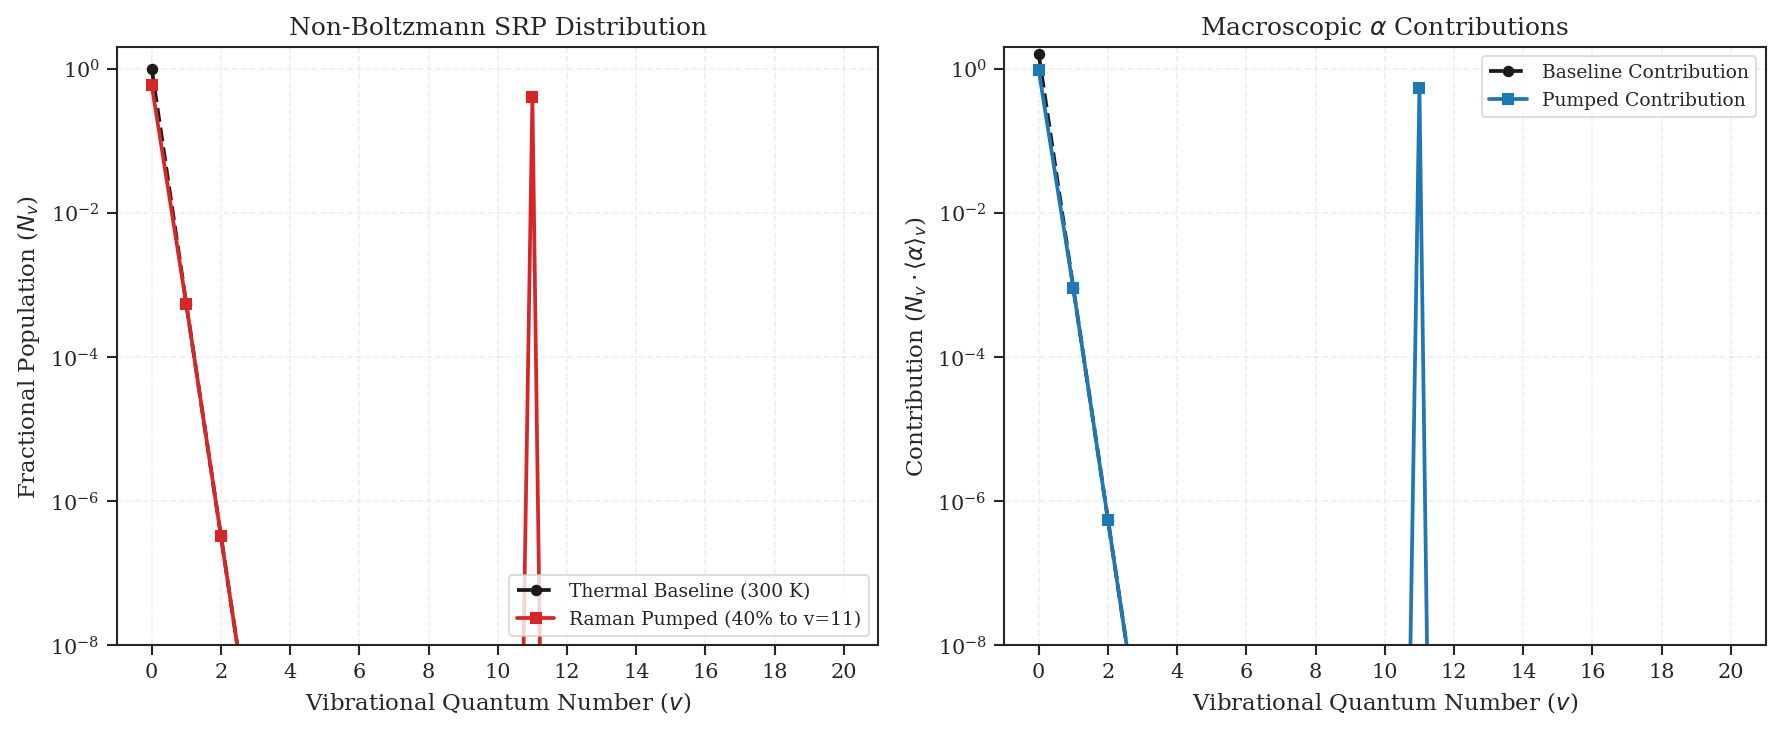

In [198]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Dissertation-Grade Plot Styling ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 11, 
    "figure.dpi": 150, 
    "grid.alpha": 0.3,
    "legend.frameon": True,
    "legend.fontsize": 9
})

# ==========================================
# 1. Constants & Configuration
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125

# Experimental Parameters
T_INITIAL = 300.0     # Cold gas temperature (K)
TARGET_V = 11        # Pump transition: v=0 -> v=12
PUMP_FRACTION = 0.40  # 40% of v=0 population inverted via SRP

# Harmonic Oscillator Assumption for O2
THETA_V = 2256.0 # K
# Conversion: k_B * Theta_v / (h * c) yields cm^-1
OMEGA_HO_CM1 = THETA_V / 1.438777 

DB_PATH = 'polarizabilities.duckdb'
TARGET_WL = '"pol_632.8nm"'  # Simulating a 632.8 nm CARS probe

# ==========================================
# 2. Database Load & Energy Split
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    (COALESCE(c.{TARGET_WL}, 0) + COALESCE(d.{TARGET_WL}, 0)) AS pol_val
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v AND c.down_J = d.down_J
    AND c.down_omega = 0 AND c.down_lambda = 0 AND c.down_sigma = 0
WHERE 
    c.down_v <= {MAX_V} AND c.down_J <= {MAX_J}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

# Isolate E_vib (J=0) and E_rot for Two-Temp logic
df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY
df['E_vib'] = df.groupby('down_v')['delta_E'].transform('min')
df['E_rot'] = df['delta_E'] - df['E_vib']

# ==========================================
# 3. Pre-Compute Rotationally Averaged Alpha (T_rot = 300K)
# ==========================================
# SRP preserves the rotational distribution, so we calculate a single
# <alpha>_v for each vibrational level assuming T_rot = T_INITIAL.

exp_rot = (-h * c * df['E_rot']) / (k_B * T_INITIAL)
df['W_rot'] = (2 * df['down_J'] + 1) * np.exp(exp_rot)
df['w_alpha'] = df['W_rot'] * df['pol_val']

# Group to get v-resolved properties
grouped = df.groupby('down_v').agg(
    sum_W_rot=('W_rot', 'sum'),
    sum_w_alpha=('w_alpha', 'sum'),
    E_vib=('E_vib', 'first')
).reset_index()

grouped['alpha_v'] = grouped['sum_w_alpha'] / grouped['sum_W_rot']

# ==========================================
# 4. Generate Distributions (Baseline vs. Pumped)
# ==========================================
# A. Baseline Thermal Distribution (300 K)
exp_vib = (-h * c * grouped['E_vib']) / (k_B * T_INITIAL)
W_vib_base = np.exp(exp_vib)
N_v_base = W_vib_base / W_vib_base.sum()

# B. Stimulated Raman Pumped Distribution
N_v_pump = N_v_base.copy()
transferred_pop = N_v_pump[0] * PUMP_FRACTION

N_v_pump[0] -= transferred_pop
N_v_pump[TARGET_V] += transferred_pop

# ==========================================
# 5. Physics Diagnostics (The 3 Layers)
# ==========================================
# Layer 1: Pump Frequency Error
freq_duo = grouped.loc[TARGET_V, 'E_vib'] - grouped.loc[0, 'E_vib']
freq_ho = TARGET_V * OMEGA_HO_CM1
detuning_error = freq_ho - freq_duo

# Layer 2 & 3: Macroscopic Polarizability Shift
alpha_macro_base = np.sum(N_v_base * grouped['alpha_v'])
alpha_macro_pump = np.sum(N_v_pump * grouped['alpha_v'])
alpha_jump_pct = ((alpha_macro_pump - alpha_macro_base) / alpha_macro_base) * 100

print(f"--- Layer 1: Experimental Laser Tuning (v=0 -> v={TARGET_V}) ---")
print(f"Exact DUO Frequency : {freq_duo:.2f} cm^-1")
print(f"Assumed HO Frequency: {freq_ho:.2f} cm^-1")
print(f"Detuning Error      : {detuning_error:.2f} cm^-1 (Experimentalist misses the line!)\n")

print(f"--- Layer 3: Macroscopic Polarizability (Probe Interpretation) ---")
print(f"Baseline Alpha (300K): {alpha_macro_base:.5f} a.u.")
print(f"Pumped Alpha (40% v={TARGET_V}): {alpha_macro_pump:.5f} a.u.")
print(f"Resulting CARS Delta : +{alpha_jump_pct:.2f}%\n")

# ==========================================
# 6. Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
v_idx = grouped['down_v']

# Plot 1: The Spiked Population
ax1.plot(v_idx, N_v_base, color='k', linestyle='--', marker='o', label='Thermal Baseline (300 K)')
ax1.plot(v_idx, N_v_pump, color='#d62728', linestyle='-', marker='s', label=f'Raman Pumped (40% to v={TARGET_V})')
ax1.set_yscale('log')
ax1.set_ylim(1e-8, 2)
ax1.set_xlabel('Vibrational Quantum Number ($v$)')
ax1.set_ylabel('Fractional Population ($N_v$)')
ax1.set_title('Non-Boltzmann SRP Distribution')
ax1.set_xticks(range(0, MAX_V + 1, 2))
ax1.grid(True, which='both', linestyle='--', alpha=0.3)
ax1.legend(loc='best')

# Plot 2: Polarizability Contribution Vector
contrib_base = N_v_base * grouped['alpha_v']
contrib_pump = N_v_pump * grouped['alpha_v']

ax2.plot(v_idx, contrib_base, color='k', linestyle='--', marker='o', label='Baseline Contribution')
ax2.plot(v_idx, contrib_pump, color='#1f77b4', linestyle='-', marker='s', label='Pumped Contribution')
ax2.set_yscale('log')
ax2.set_ylim(1e-8, 2)
ax2.set_xlabel('Vibrational Quantum Number ($v$)')
ax2.set_ylabel(r'Contribution ($N_v \cdot \langle\alpha\rangle_v$)')
ax2.set_title(r'Macroscopic $\alpha$ Contributions')
ax2.set_xticks(range(0, MAX_V + 1, 2))
ax2.grid(True, which='both', linestyle='--', alpha=0.3)
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

Temp (K) | Cont Only (A^3) |     Total (A^3)
---------------------------------------------
   300.0 |         1.58777 |         1.59127
  1200.0 |         1.60270 |         1.61620
  1700.0 |         1.60529 |         1.63320


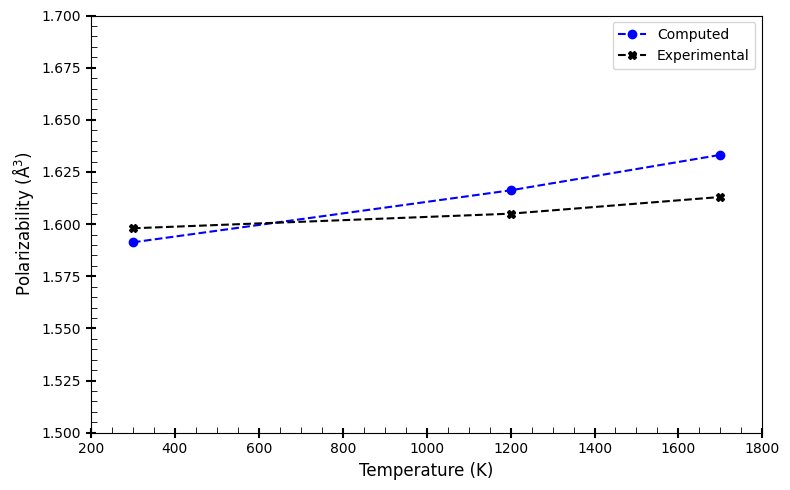

In [14]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

# ==========================================
# 1. Constants & Configuration
# ==========================================
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

GLOBAL_MIN_ENERGY = 2.8739
MAX_V = 20
MAX_J = 125

DB_PATH = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
TARGET_WL = '"pol_632.8nm"'  # Matching the 633.0 nm request

# ==========================================
# 2. Database Load
# ==========================================
query = f"""
SELECT 
    c.down_v,
    c.down_J,
    c.down_energy,
    COALESCE(c.{TARGET_WL}, 0) AS alpha_cont,
    COALESCE(d.{TARGET_WL}, 0) AS alpha_disc
FROM 
    cont_polarizabilities c
JOIN 
    discrete_polarizabilities d
    ON c.down_v = d.down_v AND c.down_J = d.down_J
    AND c.down_omega = 0 AND c.down_lambda = 0 AND c.down_sigma = 0
WHERE 
    c.down_v <= {MAX_V} AND c.down_J <= {MAX_J}
ORDER BY 
    c.down_v, c.down_J
"""

with duckdb.connect(DB_PATH) as con:
    df = con.execute(query).df()

df['delta_E'] = df['down_energy'] - GLOBAL_MIN_ENERGY

# ==========================================
# 3. Calculate Equilibrium Polarizabilities
# ==========================================
temps = [300.0, 1200.0, 1700.0]

computed_total = []
computed_cont = []

print(f"{'Temp (K)':>8} | {'Cont Only (A^3)':>15} | {'Total (A^3)':>15}")
print("-" * 45)

for T_val in temps:
    # Full thermal equilibrium: T_vib = T_rot = T_val
    exponent = (-h * c * df['delta_E']) / (k_B * T_val)
    weight = (2 * df['down_J'] + 1) * np.exp(exponent)
    
    sum_W = weight.sum()
    
    # Continuum only
    alpha_cont_macro = (weight * df['alpha_cont']).sum() / sum_W
    
    # Total (Continuum + Discrete)
    alpha_total_macro = (weight * (df['alpha_cont'] + df['alpha_disc'])).sum() / sum_W
    
    computed_cont.append(alpha_cont_macro)
    computed_total.append(alpha_total_macro)
    
    print(f"{T_val:8.1f} | {alpha_cont_macro:15.5f} | {alpha_total_macro:15.5f}")

# ==========================================
# 4. Plotting
# ==========================================
exp_data = [1.598, 1.605, 1.613]
exp_temps = temps[:len(exp_data)]

# ✅ Plotting
plt.figure(figsize=(8, 5))

# Computed (with offset/discrete): solid line
# normalize before plotting

plt.plot(temps, computed_total, label='Computed', color='blue', linestyle='--', marker='o')

# Raw (Continuum only): dashed line
# plt.plot(temps, computed_cont, label='Computed (Continuum Only)', color='red', linestyle='--', marker='o', alpha=0.7)

# Experimental validation data
# normalize before plotting

plt.plot(exp_temps, exp_data, label='Experimental', color='black', linestyle='--', marker='X')
# Labels and units
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$\mathrm{Polarizability}\ (\mathrm{\AA}^3)$', fontsize=12)
# plt.title('Equilibrium Polarizability at 632.8 nm vs Temperature', fontsize=14)

# Y range and tick formatting
plt.ylim(1.500, 1.700)
plt.xlim(200, 1800)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

# Major ticks
plt.gca().tick_params(which='major', length=7, width=1.5, direction='inout')

# Minor ticks
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(which='minor', length=4, direction='in')

# Remove grid
plt.grid(False)
plt.legend(loc='best')
plt.savefig('fig_alpha_equilibrium_632nm.jpeg', format='jpeg', dpi=400, bbox_inches='tight')
# Legend and layout
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import duckdb
import numpy as np

# 1. Convert the list of dictionaries to a DataFrame
cont_df = pd.DataFrame(results)

# 2. Extract scalar values from arrays (e.g., array([1+2j]) -> 1+2j)
# This looks at every column; if the content is an array/list, it takes the first element
for col in cont_df.columns:
    if isinstance(cont_df[col].iloc[0], (np.ndarray, list)):
        cont_df[col] = cont_df[col].apply(lambda x: x[0] if len(x) > 0 else np.nan)

# 3. Identify complex columns and split into Real and Imaginary
complex_cols = cont_df.select_dtypes(include=['complex']).columns

for col in complex_cols:
    # Create the imaginary column with the suffix
    cont_df[f"{col}_imag"] = cont_df[col].apply(lambda x: x.imag if pd.notnull(x) else 0)
    # Overwrite the original column with just the real part
    cont_df[col] = cont_df[col].apply(lambda x: x.real if pd.notnull(x) else 0)

# 4. Connect and Write to DuckDB
# Note: Using a different table name as requested
duckdb_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')

# We use the same EXCLUDE logic. If these columns don't exist in the 'results' dict, 
# DuckDB might complain, so we check if they are in the DataFrame first.
exclude_cols = ['A', 'line_pos', 'up_energy', 'up_J', 'pol_633.0nm']
actual_excludes = [f'"{c}"' if '.' in c else c for c in exclude_cols if c in cont_df.columns]
exclude_clause = f"EXCLUDE ({', '.join(actual_excludes)})" if actual_excludes else ""

duckdb_conn.execute(f"""
CREATE OR REPLACE TABLE cont_polarizabilities AS 
SELECT * {exclude_clause} FROM cont_df
""")

duckdb_conn.close()
print("Table 'cont_polarizabilities' created successfully with Real and Imaginary components.")

Table 'cont_polarizabilities' created successfully with Real and Imaginary components.


In [44]:
duckdb_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')
display(duckdb_conn.execute("SELECT * FROM discrete_polarizabilities LIMIT 5").fetchdf())
duckdb_conn.close()

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400.0nm,pol_388.0nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400.0nm_imag,pol_388.0nm_imag
0,0,0.0,0.0,0.0,0.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
1,0,1.0,0.0,1.0,1.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
2,0,2.0,0.0,0.0,0.0,17.2428,0.003335,0.003459,0.003831,0.003892,0.0,0.0,0.0,0.0
3,0,2.0,0.0,1.0,1.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
4,0,3.0,0.0,1.0,1.0,17.2428,0.003335,0.003459,0.003831,0.003892,0.0,0.0,0.0,0.0


In [ ]:
# import duckdb

# # --- Path to your database ---
# db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'

# # --- Connect to the database ---
# duckdb_conn = duckdb.connect(db_path)

# # --- Rename columns to maintain consistency (one decimal place) ---
# # Note: Double quotes are required for column names with dots
# rename_queries = [
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm TO "pol_400.0nm";',
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm TO "pol_388.0nm";',
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm_imag TO "pol_400.0nm_imag";',
#     'ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm_imag TO "pol_388.0nm_imag";'
# ]

# for query in rename_queries:
#     try:
#         duckdb_conn.execute(query)
#         print(f"Executed: {query}")
#     except Exception as e:
#         print(f"Error or column already renamed: {e}")

# # --- Verify the changes ---
# print("\nUpdated Table Schema (First 5 rows):")
# display(duckdb_conn.execute("SELECT * FROM discrete_polarizabilities LIMIT 5").fetchdf())

# duckdb_conn.close()

Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm TO "pol_400.0nm";
Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm TO "pol_388.0nm";
Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_400nm_imag TO "pol_400.0nm_imag";
Executed: ALTER TABLE discrete_polarizabilities RENAME COLUMN pol_388nm_imag TO "pol_388.0nm_imag";

Updated Table Schema (First 5 rows):


,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400.0nm,pol_388.0nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400.0nm_imag,pol_388.0nm_imag
0,0,0.0,0.0,0.0,0.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
1,0,1.0,0.0,1.0,1.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
2,0,2.0,0.0,0.0,0.0,17.2428,0.003335,0.003459,0.003831,0.003892,0.0,0.0,0.0,0.0
3,0,2.0,0.0,1.0,1.0,2.8739,0.003324,0.003447,0.003819,0.003879,0.0,0.0,0.0,0.0
4,0,3.0,0.0,1.0,1.0,17.2428,0.003335,0.003459,0.003831,0.003892,0.0,0.0,0.0,0.0


In [38]:
duckdb_conn = duckdb.connect('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb')
display(duckdb_conn.execute("SELECT * FROM cont_polarizabilities LIMIT 5").fetchdf())
duckdb_conn.close()

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400.0nm,pol_388.0nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400.0nm_imag,pol_388.0nm_imag
0,0,0.0,0.0,0.0,0.0,2.8652,1.658758e-38,1.697511e-38,1.808499e-38,1.825776e-38,2.309513e-43,2.879490e-43,4.358431e-43,4.581464e-43
1,0,1.0,0.0,1.0,1.0,2.8652,1.658758e-38,1.697511e-38,1.808499e-38,1.825776e-38,2.309513e-43,2.879490e-43,4.358431e-43,4.581464e-43
2,0,2.0,0.0,0.0,0.0,17.1904,1.658935e-38,1.697698e-38,1.808718e-38,1.826001e-38,2.310130e-43,2.880284e-43,4.359741e-43,4.582860e-43
3,0,2.0,0.0,1.0,1.0,2.8652,1.658758e-38,1.697511e-38,1.808499e-38,1.825776e-38,2.309513e-43,2.879490e-43,4.358431e-43,4.581464e-43
4,0,3.0,0.0,1.0,1.0,17.1904,1.658935e-38,1.697698e-38,1.808718e-38,1.826001e-38,2.310130e-43,2.880284e-43,4.359741e-43,4.582860e-43


In [ ]:
# # Multiplier code, run only once
# import numpy as np

# # Calculate the constant scalar
# # Multiplier = (e^2 * 1e30) / (me * epsilon_0)
# MULTIPLIER_CONT = (1e30 * 3e8) / np.pi

# print(f"Calculated Multiplier: {MULTIPLIER_CONT:.4e}")

# import duckdb

# # Connect to your database
# db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
# duckdb_conn = duckdb.connect(db_path)

# # Apply the multiplier to the Real and Imaginary components
# # Assuming you have both pol_xxx and pol_xxx_imag columns
# columns_to_update = [
#     "pol_532.0nm", "pol_532.0nm_imag",
#     "pol_388.0nm", "pol_388.0nm_imag",
#     "pol_632.8nm", "pol_632.8nm_imag", 
#     "pol_400.0nm", "pol_400.0nm_imag"
# ]

# # Construct the SET clause: "column" = "column" * MULTIPLIERa
# set_clause = ", ".join([f'"{col}" = "{col}" * {MULTIPLIER_CONT}' for col in columns_to_update])

# try:
#     duckdb_conn.execute(f"UPDATE cont_polarizabilities SET {set_clause}")
#     print("Successfully multiplied columns by physical constants.")
# except Exception as e:
#     print(f"Error: {e}")
#     print("Ensure all column names (including _imag) exist in the table.")

# # Verify a sample
# display(duckdb_conn.execute("SELECT * FROM cont_polarizabilities LIMIT 1").df())

# duckdb_conn.close()

Calculated Multiplier: 9.5493e+37
Successfully multiplied columns by physical constants.


,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,pol_632.8nm,pol_532.0nm,pol_400.0nm,pol_388.0nm,pol_632.8nm_imag,pol_532.0nm_imag,pol_400.0nm_imag,pol_388.0nm_imag
0,0,0.0,0.0,0.0,0.0,2.8652,1.583998,1.621004,1.726989,1.743488,0.000022,0.000027,0.000042,0.000044


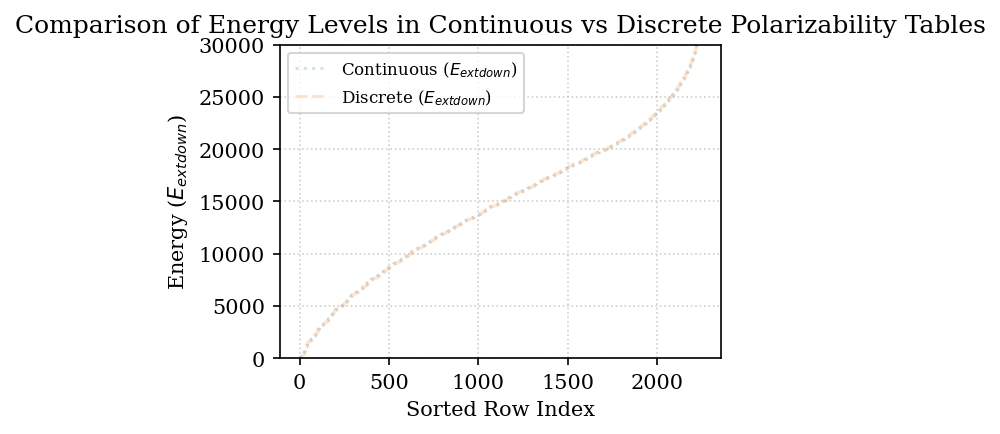

In [40]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to the database
db_path = '/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/polarizabilities.duckdb'
duckdb_conn = duckdb.connect(db_path)

# 2. Extract down_energy from both tables
# We use .df() to bring them into Pandas for easy sorting and plotting
try:
    df_cont = duckdb_conn.execute("SELECT down_energy FROM cont_polarizabilities where down_v < 15 and down_J<100").df()
    df_disc = duckdb_conn.execute("SELECT down_energy FROM discrete_polarizabilities where down_v < 15 and down_J<100").df()
finally:
    duckdb_conn.close()

# 3. Sort the energies in ascending order
# This allows us to visualize the energy "ladder" or density of states
energies_cont = sorted(df_cont['down_energy'].dropna())
energies_disc = sorted(df_disc['down_energy'].dropna())

# 4. Generate the plot
plt.figure(figsize=(4,3))

# Plotting each as a function of their own index
plt.plot(range(len(energies_cont)), energies_cont, label='Continuous ($E_{\text{down}}$)', 
          linestyle=':', alpha=0.2)
plt.plot(range(len(energies_disc)), energies_disc, label='Discrete ($E_{\text{down}}$)', 
          linestyle='--', alpha=0.2)

# Formatting using LaTeX for scientific notation
plt.xlabel('Sorted Row Index')
plt.ylabel('Energy ($E_{\text{down}}$)')
plt.ylim(0, 30000)  # Adjust as needed to focus on the relevant energy range
plt.title('Comparison of Energy Levels in Continuous vs Discrete Polarizability Tables')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Ensure labels aren't truncated
plt.tight_layout()

# Save the figure to your directory
# plt.savefig('/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/energy_plot.png', dpi=300)
# plt.show() # Uncomment if running in an interactive session

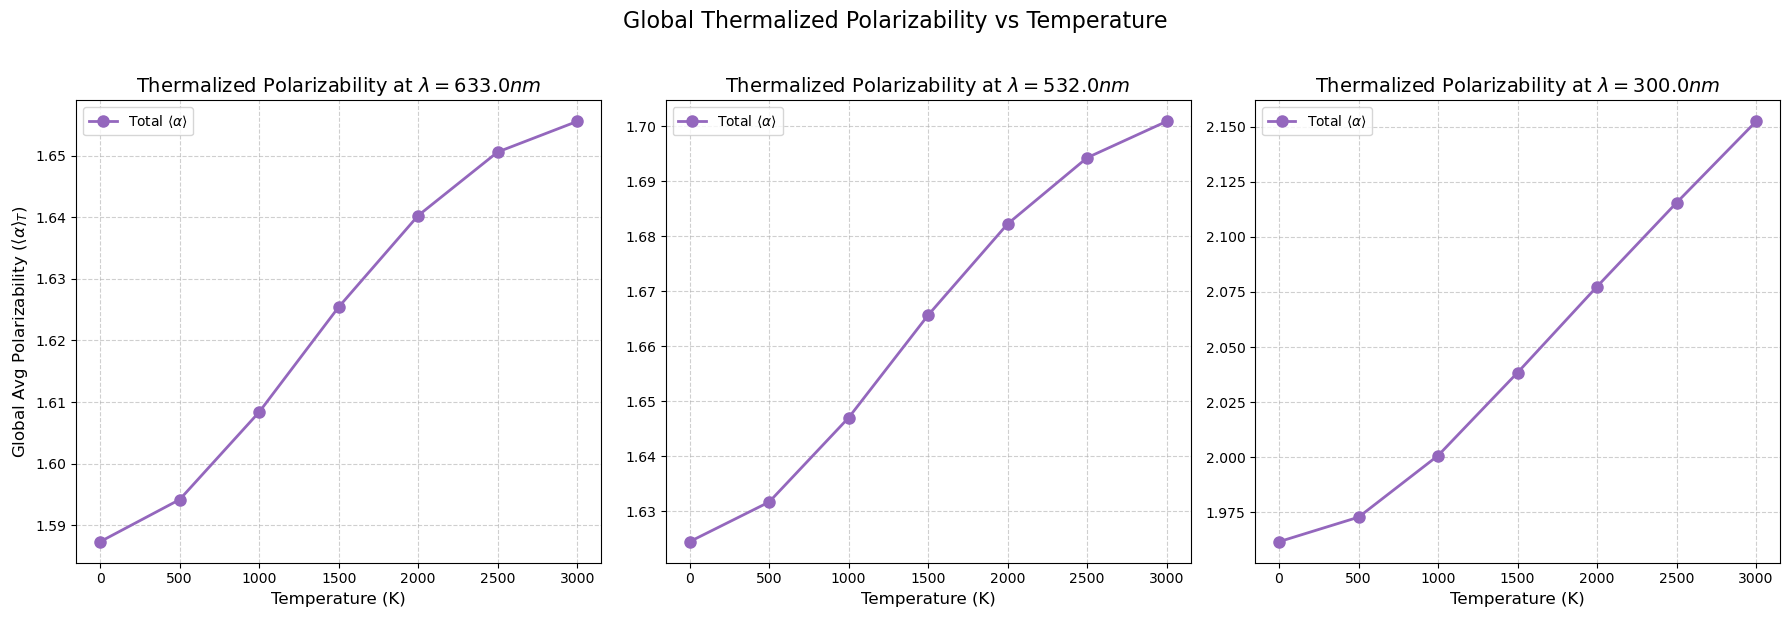


--- Final Fully Thermalized Polarizability Values ---
 Temperature (K)  633.0nm  532.0nm  300.0nm
             0.1 1.587319 1.624504 1.961730
           500.0 1.594159 1.631714 1.972857
          1000.0 1.608372 1.647039 2.000786
          1500.0 1.625429 1.665691 2.038439
          2000.0 1.640287 1.682284 2.077478
          2500.0 1.650605 1.694317 2.115516
          3000.0 1.655579 1.700924 2.152392


In [42]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Define Constants and Parameters ---
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

# Multipliers
epsilon_0 = 8.8541878128e-12  
me = 9.10938356e-31 
e = 1.602176634e-19 

MULTIPLIER_CONT = (1e30 * 3e8) / np.pi
MULTIPLIER_DISC = (e**2 * 1e30) / (me * epsilon_0)

wavelength_keys = ['pol_633.0nm', 'pol_532.0nm', 'pol_300.0nm']

# Expanding the temperature range slightly to make a nice curve, 
# while making sure your specific target temperatures are included.
target_Temps = np.array([0.10, 500, 1000, 1500, 2000, 2500, 3000])
max_v = 26  # Cutoff for vibrational level

# --- 2. Load and Merge Data into Unified States ---
# We will combine Continuum and Discrete data into a single dictionary keyed by (v, J)
unified_states = {}

# Load Continuum Data (Assuming `results` is in memory)
for r in results:
    v = r['down_v']
    if v <= max_v:
        J = r['down_J']
        state_key = (v, J)
        
        unified_states[state_key] = {
            'energy': r['down_energy'],
            'J': J,
            'cont_alphas': {k: (complex(r[k][0]) * MULTIPLIER_CONT).real for k in wavelength_keys},
            'disc_alphas': {k: 0.0 for k in wavelength_keys} # Default to 0 until loaded
        }

# Load Discrete Data from Pickle
df_discrete = pd.read_pickle('full_discrete_pol.pkl')
discrete_results = df_discrete.to_dict('records')

for r in discrete_results:
    v = r['down_v']
    if v <= max_v:
        J = r['down_J']
        state_key = (v, J)
        
        # If the state exists in continuum, update the discrete values. 
        # If not, create it.
        if state_key not in unified_states:
            unified_states[state_key] = {
                'energy': r['down_energy'],
                'J': J,
                'cont_alphas': {k: 0.0 for k in wavelength_keys},
                'disc_alphas': {}
            }
            
        for k in wavelength_keys:
            unified_states[state_key]['disc_alphas'][k] = (complex(r[k]) * MULTIPLIER_DISC).real

# --- 3. Find Global Minimum Energy ---
# This is the new zero-point for the global Boltzmann distribution (usually v=0, J=0)
global_E_min = min([state['energy'] for state in unified_states.values()])

# --- 4. Compute Global Boltzmann Average ---
final_results = {k: [] for k in wavelength_keys}

for T in target_Temps:
    
    # Dictionaries to hold the running numerator/denominator for each wavelength
    numerators = {k: 0.0 for k in wavelength_keys}
    denominator = 0.0
    
    for state in unified_states.values():
        J = state['J']
        E_state = state['energy']
        
        # Calculate global Boltzmann weight for this state
        delta_E = E_state - global_E_min
        weight = (2 * J + 1) * np.exp(-h * c * delta_E / (k_B * T))
        
        denominator += weight
        
        # Add the weighted total polarizability to the numerator
        for k in wavelength_keys:
            total_alpha = state['cont_alphas'][k] + state['disc_alphas'][k]
            numerators[k] += total_alpha * weight
            
    # Finalize the average for this Temperature
    for k in wavelength_keys:
        if denominator == 0:
            final_results[k].append(0.0)
        else:
            final_results[k].append(numerators[k] / denominator)

# --- 5. Setup the Plotting Environment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, pol_key in enumerate(wavelength_keys):
    ax = axes[i]
    wv_label = pol_key.replace("pol_", "")
    
    # Plot Total Polarizability vs Temperature
    ax.plot(target_Temps, final_results[pol_key], marker='o', linestyle='-', 
            color='tab:purple', linewidth=2, markersize=8, label='Total $\langle\\alpha\\rangle$')
    
    # --- Formatting ---
    ax.set_title(f'Thermalized Polarizability at $\lambda = {wv_label}$', fontsize=14)
    ax.set_xlabel('Temperature (K)', fontsize=12)
    
    if i == 0:
        ax.set_ylabel(r'Global Avg Polarizability ($\langle\alpha\rangle_{T}$)', fontsize=12)
        
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

# --- 6. Final Layout Adjustments ---
plt.suptitle('Global Thermalized Polarizability vs Temperature', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- Optional: Print the exact values ---
print("\n--- Final Fully Thermalized Polarizability Values ---")
df_final = pd.DataFrame({'Temperature (K)': target_Temps})
for k in wavelength_keys:
    df_final[k.replace("pol_", "")] = final_results[k]
print(df_final.to_string(index=False))

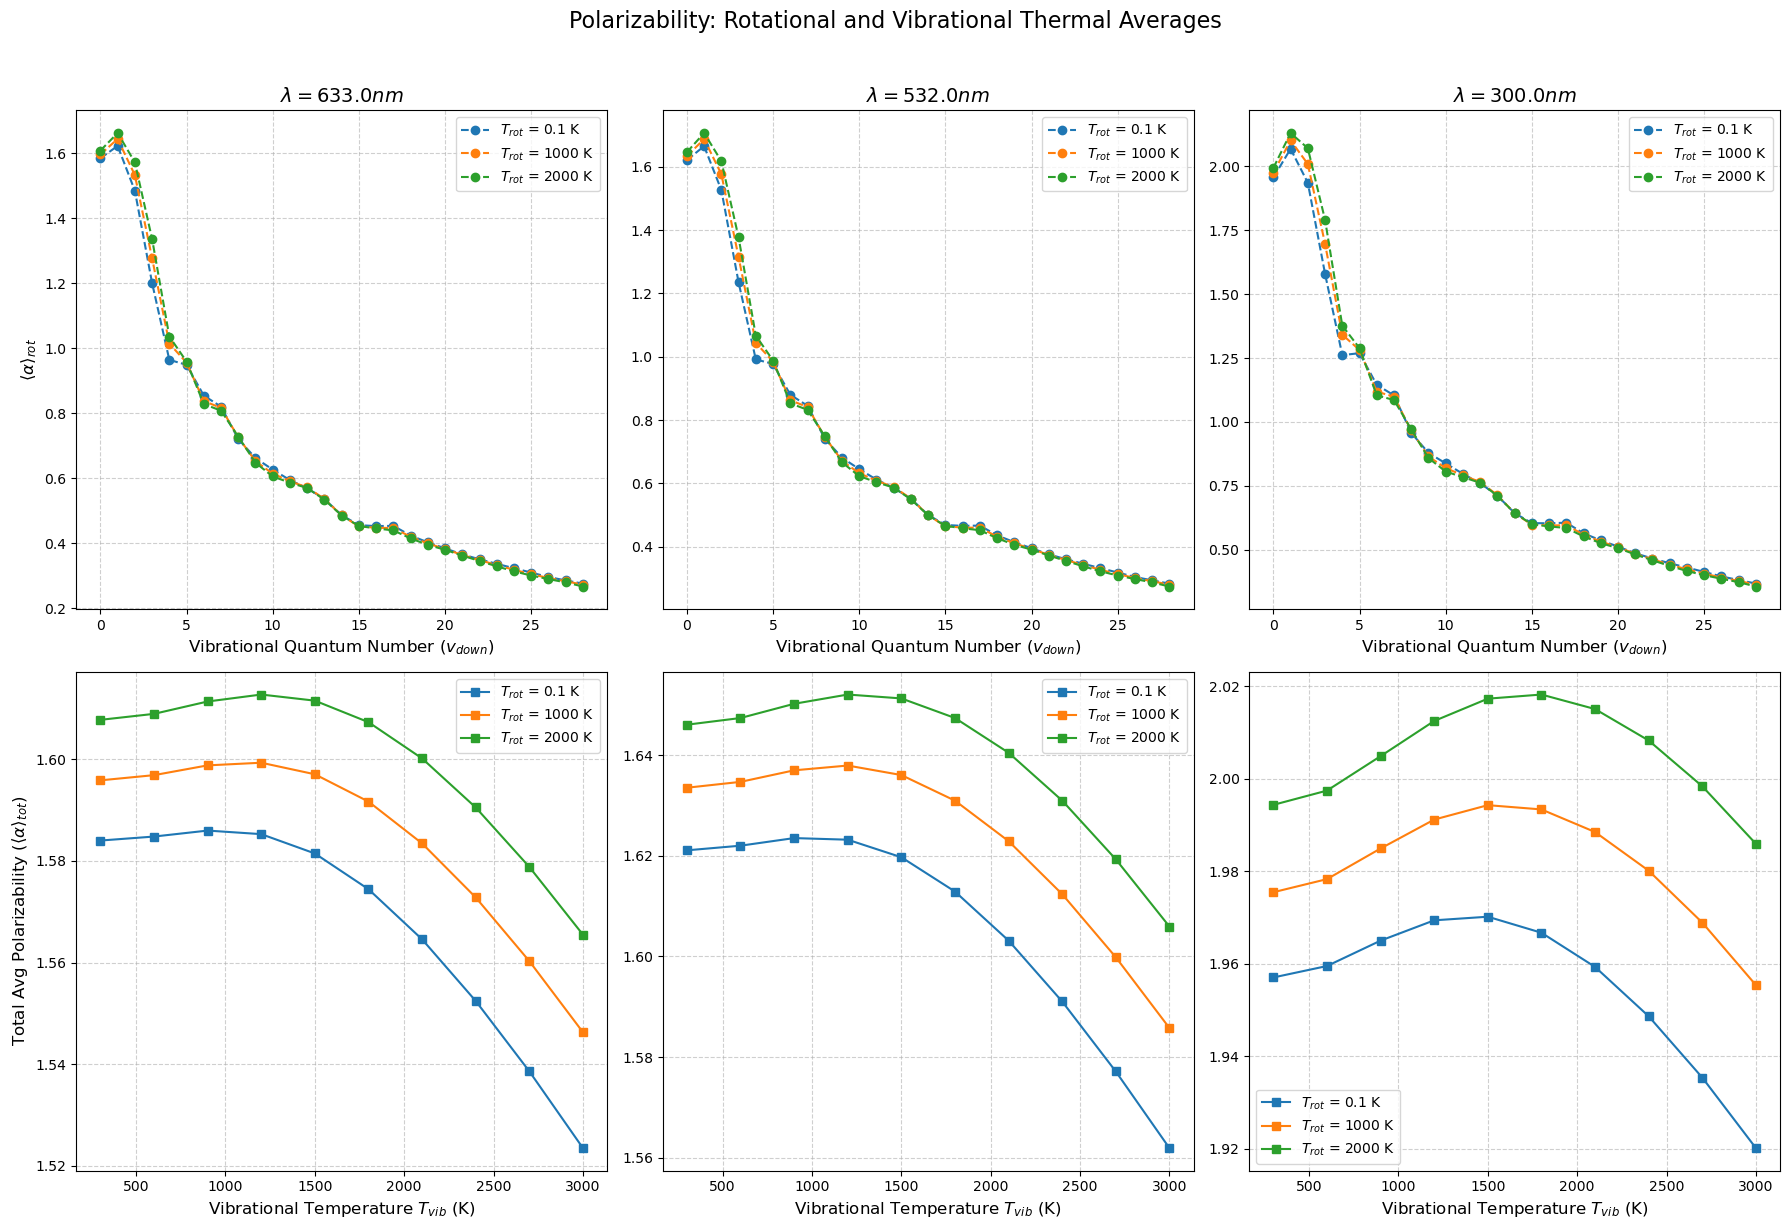

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Constants and Parameters ---
c = 2.99792458e10       # speed of light in cm/s
h = 6.62607015e-34      # Planck's constant in J*s
k_B = 1.380649e-23      # Boltzmann's constant in J/K

# Multiplier from your snippet
MULTIPLIER = (1e30 * 3e8) / np.pi

# The specific keys we want to plot (Wavelengths)
wavelength_keys = ['pol_633.0nm', 'pol_532.0nm', 'pol_300.0nm']

# The specific Rotational Temperatures we want to compare
target_Temps = [0.10, 1000, 2000]

# NEW: The Vibrational Temperatures for the second row of plots
target_T_vib = np.arange(300, 3300, 300) # 300, 600, 900 ... 3000

# --- 2. Helper: Group Data by Vibrational Level ---
# structure: { v_level: [ list of result dictionaries for this v ] }
data_by_v = {}
for r in results:  # Assuming 'results' is loaded elsewhere in your environment
    v = r['down_v']
    if v not in data_by_v:
        data_by_v[v] = []
    data_by_v[v].append(r)

# Get sorted list of v levels for consistent plotting
sorted_v_levels = sorted(data_by_v.keys())

# --- 3. Setup the Plotting Environment ---
# Extended to 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=False)

# Loop through each wavelength (each column)
for i, pol_key in enumerate(wavelength_keys):
    ax_row1 = axes[0, i]
    ax_row2 = axes[1, i]
    
    # Loop through the requested Rotational Temperatures (each series)
    for T_rot in target_Temps:
        
        v_list = []
        avg_alpha_list = []
        v_energies = [] # To store the band origin (E_vib) for each v level
        
        # Iterate through each vibrational level to compute the weighted average
        for v in sorted_v_levels:
            entries = data_by_v[v]
            
            # --- FIND BAND ORIGIN (E_min for this v) ---
            energies_in_band = [r['down_energy'] for r in entries]
            E_v_origin = min(energies_in_band) 
            
            alphas = []
            weights = []
            
            # 1. Collect Alpha and RELATIVE Boltzmann factor for each J
            for r in entries:
                J = r['down_J']
                E_rot = r['down_energy']
                
                # Extract Polarizability
                pol_complex = r[pol_key][0]
                alpha_real = (pol_complex * MULTIPLIER).real
                alphas.append(alpha_real)
                
                # Calculate energy relative to the band origin (J=0 of this v)
                delta_E = E_rot - E_v_origin
                
                # Rotational Boltzmann factor
                factor = (2 * J + 1) * np.exp(-h * c * delta_E / (k_B * T_rot))
                weights.append(factor)
            
            # 2. Normalize weights
            weights = np.array(weights)
            weight_sum = np.sum(weights)
            norm_weights = np.zeros_like(weights) if weight_sum == 0 else weights / weight_sum
            
            # 3. Compute Rotational Weighted Average
            weighted_avg_alpha = np.sum(norm_weights * np.array(alphas))
            
            # Store for Row 1
            v_list.append(v)
            avg_alpha_list.append(weighted_avg_alpha)
            
            # Store E_vib for Row 2 calculations
            v_energies.append(E_v_origin)
        
        # --- 4. Plot Row 1 (f(vib) at fixed T_rot) ---
        ax_row1.plot(v_list, avg_alpha_list, marker='o', linestyle='--', label=r'$T_{rot}$' + f' = {T_rot} K')
        
        # --- 5. Calculate and Plot Row 2 (Total Avg Polarizability vs T_vib) ---
        tot_avg_alphas = []
        E_vib_0 = min(v_energies) # The absolute ground state energy (v=0)
        
        for T_vib in target_T_vib:
            vib_weights = []
            
            # Calculate vibrational Boltzmann fraction for each v
            for E_v in v_energies:
                delta_E_vib = E_v - E_vib_0
                
                # Degeneracy is 1 (equivalent to 2*J+1 where J=0)
                vib_factor = 1 * np.exp(-h * c * delta_E_vib / (k_B * T_vib))
                vib_weights.append(vib_factor)
                
            vib_weights = np.array(vib_weights)
            Q_vib = np.sum(vib_weights)
            norm_vib_weights = np.zeros_like(vib_weights) if Q_vib == 0 else vib_weights / Q_vib
            
            # Total average = Sum of (vib_fraction * rotationally_averaged_alpha)
            tot_avg_alpha = np.sum(norm_vib_weights * np.array(avg_alpha_list))
            tot_avg_alphas.append(tot_avg_alpha)
            
        ax_row2.plot(target_T_vib, tot_avg_alphas, marker='s', linestyle='-', label=r'$T_{rot}$' + f' = {T_rot} K')

    # --- 6. Formatting for both rows ---
    wv_label = pol_key.replace("pol_", "")
    
    # Format Top Row
    ax_row1.set_title(f'$\lambda = {wv_label}$', fontsize=14)
    ax_row1.set_xlabel('Vibrational Quantum Number ($v_{down}$)', fontsize=12)
    ax_row1.grid(True, linestyle='--', alpha=0.6)
    ax_row1.legend()
    
    # Format Bottom Row
    ax_row2.set_xlabel('Vibrational Temperature $T_{vib}$ (K)', fontsize=12)
    ax_row2.grid(True, linestyle='--', alpha=0.6)
    ax_row2.legend()
    
    if i == 0:
        ax_row1.set_ylabel(r'$\langle\alpha\rangle_{rot}$', fontsize=12)
        ax_row2.set_ylabel(r'Total Avg Polarizability ($\langle\alpha\rangle_{tot}$)', fontsize=12)

# --- 7. Final Layout ---
plt.suptitle('Polarizability: Rotational and Vibrational Thermal Averages', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Can now use the above temperature agnostic cross-sections to generate temperature_dependent cross_sections and polarizability. The polarizability however, is raw, meaning it needs to be multipled by several constants.

In [34]:
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K
T = [300,1200,1700, 3000]  # Temperature in Kelvin
Q_T = [219.6, 1030, 1703, 4266]
Q_T = [Q(T_i) for T_i in T]  # Partition function for each temperature
for (T_i, Q_i) in zip(T, Q_T):
    print(f"Partition function at {T_i} K: {Q_i:.6f}")

master_cross_section_data = {}  # stores sigma_total arrays keyed by temperature
master_polarizability = {} # stores polarizability dictionaries keyed by temperature and sensing wavelength



for (T_i, Q_i) in zip(T, Q_T):
    boltz_factors = []
    
    for r in results:
        E = r['down_energy']             # in cm⁻¹
        J = r['down_J']
        boltz = (2 * J + 1) * np.exp(-h * c * (E) / (k_B * T_i)) / Q_i
        boltz = (2 * J + 1) * np.exp(-h * c * (E - 2.8652) / (k_B * T_i)) / Q_i
        boltz_factors.append(boltz)

    boltz_factors = np.array(boltz_factors) 

    # Step 2: Compute weighted sum of cross sections
    sigma_total = np.zeros_like(nu_range)    
    pol_totals = {}  # key: 'pol_632.8nm', value: complex

    for r, w in zip(results, boltz_factors):
        sigma_total += w * np.array(r['cross_section'][0])
        # Accumulate polarizability contributions for all sensing wavelengths
        for key in r:
            if key.startswith('pol_') and key.endswith('nm'):
                if key not in pol_totals:
                    pol_totals[key] = 0
                pol_totals[key] += w * r[key]

    # Store in master dictionary
    master_cross_section_data[f"CrossSection@{T_i:.1f}K"] = sigma_total
    master_polarizability[f"Polarizability@{T_i:.1f}K"] = pol_totals

print (master_cross_section_data.keys())
master_polarizability


Partition function at 300 K: 219.153204
Partition function at 1200 K: 1037.768002
Partition function at 1700 K: 1703.509474
Partition function at 3000 K: 4246.989340
dict_keys(['CrossSection@300.0K', 'CrossSection@1200.0K', 'CrossSection@1700.0K', 'CrossSection@3000.0K'])


{'Polarizability@300.0K': {'pol_633.0nm': array([1.68542536e-38+2.3512411e-43j]),
  'pol_532.0nm': array([1.72495452e-38+2.93301421e-43j]),
  'pol_300.0nm': array([2.08349496e-38+7.65899128e-43j])},
 'Polarizability@1200.0K': {'pol_633.0nm': array([1.68345942e-38+2.41829708e-43j]),
  'pol_532.0nm': array([1.72415321e-38+3.02221901e-43j]),
  'pol_300.0nm': array([2.09697655e-38+8.04232395e-43j])},
 'Polarizability@1700.0K': {'pol_633.0nm': array([1.68424656e-38+2.47624636e-43j]),
  'pol_532.0nm': array([1.72594759e-38+3.09943011e-43j]),
  'pol_300.0nm': array([2.11130315e-38+8.38382582e-43j])},
 'Polarizability@3000.0K': {'pol_633.0nm': array([1.65489817e-38+2.56231251e-43j]),
  'pol_532.0nm': array([1.69812598e-38+3.21872113e-43j]),
  'pol_300.0nm': array([2.10582844e-38+9.05229277e-43j])}}

In [35]:
# find magnitude of the complex number polarizability at 300K and 632.8nm
print ((master_polarizability['Polarizability@300.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real)
print ((master_polarizability['Polarizability@1200.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real)
print ((master_polarizability['Polarizability@1700.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real)
print ((master_polarizability['Polarizability@3000.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real)
# print ((master_polarizability['Polarizability@300.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real   + 0.01087395189324547)
# print ((master_polarizability['Polarizability@1200.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real   + 0.047593118926718796)
# print ((master_polarizability['Polarizability@1700.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real   + 0.10471277339036666)
# print ((master_polarizability['Polarizability@3000.0K']['pol_633.0nm'][0] * (1e30*3e8/np.pi)).real   + 0.31846146646343704)
# (master_polarizability['Polarizability@300.0K']['pol_632.8nm'][0]* 4*(1e30*(299792458*299792458)*6.626*1e-34/(4*9.81*9.81*8.8541878128e-12))).real

1.6094626638734928
1.6075853248145717
1.6083369899569722
1.5803113458624276


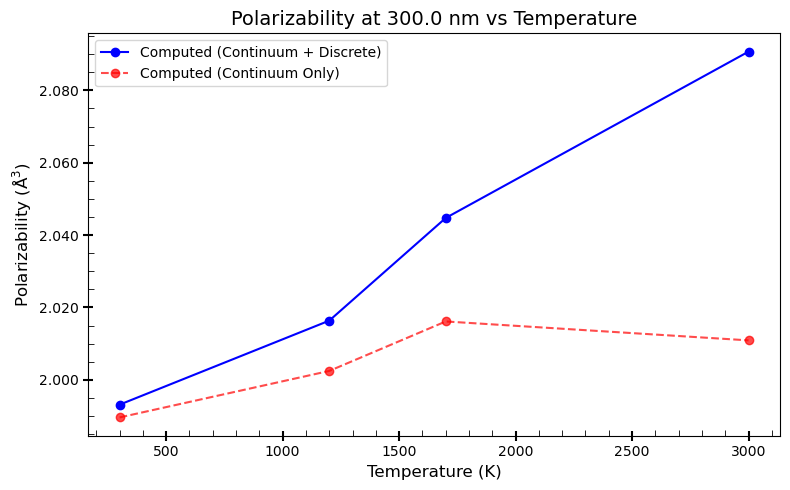

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

# Constants
scale_factor = 1e30 * 3e8 / (np.pi)

# Temperatures (K) and corresponding offsets
temps = [300.0, 1200.0, 1700.0, 3000.0]
offsets = [0.01087395189324547, 0.047593118926718796, 0.10471277339036666, 0.31846146646343704]
offsets = [0.0001929, 0.010831282043284571, 0.01693735821345986, 0.02556003342949301]
offsets = [0.00353,0.0139,0.0286,0.0798]

# 300 - 0.00353
# 1200 - 0.0139
# 1700 - 0.0286
# 3000 - 0.0798 with 4246 and 0.0794 with 4266


# Lists for polarizability values
computed_data = []
raw_data = []

for T_val, offset in zip(temps, offsets):
    alpha = master_polarizability[f'Polarizability@{T_val}K']['pol_300.0nm']
    
    scaled_raw = (alpha * scale_factor).real          # Without offset
    scaled_offset = scaled_raw + offset/(1)    # With offset

    raw_data.append(scaled_raw)
    computed_data.append(scaled_offset)

# Updated experimental data
exp_data = [1.598, 1.605, 1.613]
exp_temps = temps[:len(exp_data)]

# ✅ Plotting
plt.figure(figsize=(8, 5))

# Computed (with offset): solid line
plt.plot(temps, computed_data, label='Computed (Continuum + Discrete)', color='blue', linestyle='-', marker='o')

# Raw (no offset): dashed line
plt.plot(temps, raw_data, label='Computed (Continuum Only)', color='red', linestyle='--', marker='o', alpha=0.7)

# Experimental validation data
# plt.scatter(exp_temps, exp_data, label='Experimental', color='black', marker='X', s=90, edgecolors='black')


# Labels and units
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$\mathrm{Polarizability}\ (\mathrm{\AA}^3)$', fontsize=12)
plt.title('Polarizability at 300.0 nm vs Temperature', fontsize=14)

# Y range and tick formatting
# plt.ylim(1.400, 1.900)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

# Major ticks
plt.gca().tick_params(which='major', length=7, width=1.5, direction='inout')

# Minor ticks
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(which='minor', length=4, direction='in')

# Remove grid
plt.grid(False)
# Legend and layout
plt.legend()
plt.tight_layout()
plt.show()

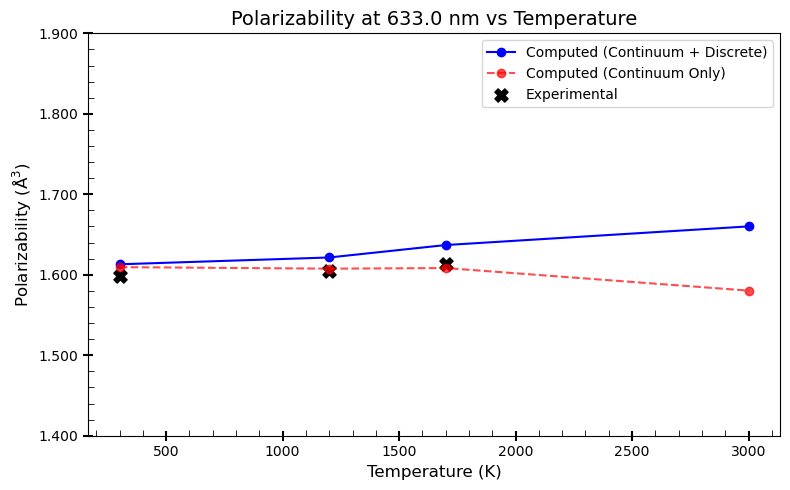

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

# Constants
scale_factor = 1e30 * 3e8 / np.pi

# Temperatures (K) and corresponding offsets
temps = [300.0, 1200.0, 1700.0, 3000.0]
offsets = [0.01087395189324547, 0.047593118926718796, 0.10471277339036666, 0.31846146646343704]
offsets = [0.0001929, 0.010831282043284571, 0.01693735821345986, 0.02556003342949301]
offsets = [0.00353,0.0139,0.0286,0.0798]

# 300 - 0.00353
# 1200 - 0.0139
# 1700 - 0.0286
# 3000 - 0.0798 with 4246 and 0.0794 with 4266


# Lists for polarizability values
computed_data = []
raw_data = []

for T_val, offset in zip(temps, offsets):
    alpha = master_polarizability[f'Polarizability@{T_val}K']['pol_633.0nm']
    
    scaled_raw = (alpha * scale_factor).real          # Without offset
    scaled_offset = scaled_raw + offset    # With offset

    raw_data.append(scaled_raw)
    computed_data.append(scaled_offset)

# Updated experimental data
exp_data = [1.598, 1.605, 1.613]
exp_temps = temps[:len(exp_data)]

# ✅ Plotting
plt.figure(figsize=(8, 5))

# Computed (with offset): solid line
plt.plot(temps, computed_data, label='Computed (Continuum + Discrete)', color='blue', linestyle='-', marker='o')

# Raw (no offset): dashed line
plt.plot(temps, raw_data, label='Computed (Continuum Only)', color='red', linestyle='--', marker='o', alpha=0.7)

# Experimental validation data
plt.scatter(exp_temps, exp_data, label='Experimental', color='black', marker='X', s=90, edgecolors='black')

# Labels and units
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$\mathrm{Polarizability}\ (\mathrm{\AA}^3)$', fontsize=12)
# plt.title('Polarizability at 633.0 nm vs Temperature', fontsize=14)

# Y range and tick formatting
plt.ylim(1.400, 1.900)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

# Major ticks
plt.gca().tick_params(which='major', length=7, width=1.5, direction='inout')

# Minor ticks
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(which='minor', length=4, direction='in')

# Remove grid
plt.grid(False)
# Legend and layout
plt.legend()
plt.tight_layout()
plt.show()

## Pending changes - 7/23
- Converge on only one Q engine 
- Fix the number of levels across both transitions 
- CHECK ALL THE MATH!!
